
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 1

# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

### 1.0 Enfoque adoptado

Para responder la pregunta hay tres caminos metodológicos razonables: comparar las distribuciones de sueldo por lenguaje con visualizaciones, comparar medidas de estadística descriptiva por lenguaje, o comparar probabilidades condicionales. En este trabajo se combinan los dos primeros enfoques: la visualización responde la pregunta principal de forma intuitiva y las medidas descriptivas la respaldan cuantitativamente. Se deja constancia explícita de la combinación para evitar ambigüedad sobre qué enfoque alimenta cada conclusión.

> Todas las observaciones que siguen deben leerse como propiedades de la muestra analizada, bajo los filtros aplicados. No se realizan inferencias a la población general ni tests estadísticos; esas herramientas se abordan en otra etapa del trabajo.

| N INICIAL | N FINAL (FILTRADO) | LENGUAJES ÚNICOS | EN EL RANKING|
| :--- | :--- | :--- | :--- |
| 4939 |4207|160|26|

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn
import ptitprince
from sklearn.linear_model import LinearRegression

seaborn.set_context('talk')

In [ ]:
# Registro de cuadros para la exportación final
cuadros_exportables: dict[str, pd.DataFrame | pd.Series] = {}


def mostrar(nombre: str, obj) -> None:
    """Imprime un cuadro con encabezado y lo registra para CSV opcional."""
    sep = '━' * max(3, 70 - len(nombre))
    print(f'\n━━━ {nombre} {sep}')
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        print(obj.to_string())
        cuadros_exportables[nombre] = obj
    else:
        print(obj)

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df_original = pd.read_csv(url)

N_INICIAL = len(df_original)

metadatos_carga = pd.DataFrame({
    'métrica': ['archivo', 'filas iniciales', 'columnas totales'],
    'valor': ['sysarmy_survey_2026_processed.csv', N_INICIAL, len(df_original.columns)],
})
mostrar('1.0  Carga del conjunto de datos', metadatos_carga)

enfoque_ej1 = pd.DataFrame({
    'elemento': ['opción elegida', 'visualización', 'soporte cuantitativo'],
    'decisión': [
        'A + B combinadas',
        'distribuciones por lenguaje (G1-G4)',
        'mediana, cuartiles, IQR y CV robusto',
    ],
})
mostrar('1.0  Enfoque adoptado para el ejercicio 1', enfoque_ej1)


━━━ 1.0  Carga del conjunto de datos ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            métrica                              valor
0           archivo  sysarmy_survey_2026_processed.csv
1   filas iniciales                               4939
2  columnas totales                                 60

━━━ 1.0  Enfoque adoptado para el ejercicio 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               elemento                              decisión
0        opción elegida                      A + B combinadas
1         visualización   distribuciones por lenguaje (G1-G4)
2  soporte cuantitativo  mediana, cuartiles, IQR y CV robusto


### 1.1 Selección de columnas relevantes

Del conjunto de datos original se retienen **12 columnas**, estrictamente las necesarias para responder la pregunta del ejercicio. Las variables críticas son:

* **`tools_programming_languages`**: Variable explicativa principal.
* **`salary_monthly_NETO`**: Variable respuesta.
* **`salary_in_usd`**: Tipo de dolarización del sueldo.
* **`work_dedication`**: Filtro de homogeneidad (jornada).
* **`work_contract_type`**: Filtro de homogeneidad (tipo de contrato).

---

> **Estrategia de limpieza:** Trabajar con un subconjunto acotado facilita la **auditoría del código** y la **lectura del análisis**. Las variables descartadas pueden reincorporarse en los ejercicios siguientes si aportan información relevante.

In [ ]:
# complete here if you want to include more columns
relevant_columns = [
    'tools_programming_languages',
    'salary_monthly_NETO',
    'salary_monthly_BRUTO',
    'salary_in_usd',
    'work_dedication',
    'work_contract_type',
    'profile_years_experience',
    'profile_age',
    'work_seniority',
    'profile_studies_level',
    'profile_studies_level_state',
    'profile_gender',
]

In [ ]:
columnas_retenidas = pd.DataFrame({
    'columna': relevant_columns,
    'descripción': [
        'Lenguajes de programación utilizados',
        'Salario mensual neto declarado',
        'Salario mensual bruto declarado',
        'Salario mensual en USD declarado',
        'Dedicación laboral (full-time, part-time, etc.)',
        'Tipo de contrato laboral (indefinido, temporal, etc.)',
        'Años de experiencia profesional',
        'Edad del encuestado',
        'Antigüedad en el puesto actual',
        'Nivel educativo alcanzado',
        'Estado del nivel educativo alcanzado (completo/incompleto)',
        'Género declarado por el encuestado',
    ],
})

mostrar('1.1  Columnas retenidas', columnas_retenidas)
print(f'\n  columnas descartadas: '
      f'{len(df_original.columns) - len(relevant_columns)}')

df = df_original[relevant_columns].copy()


━━━ 1.1  Columnas retenidas ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        columna                                                 descripción
0   tools_programming_languages                        Lenguajes de programación utilizados
1           salary_monthly_NETO                              Salario mensual neto declarado
2          salary_monthly_BRUTO                             Salario mensual bruto declarado
3                 salary_in_usd                            Salario mensual en USD declarado
4               work_dedication             Dedicación laboral (full-time, part-time, etc.)
5            work_contract_type       Tipo de contrato laboral (indefinido, temporal, etc.)
6      profile_years_experience                             Años de experiencia profesional
7                   profile_age                                         Edad del encuestado
8                work_seniority                              Antigüedad en el puesto actual
9  

### 1.2 Análisis de la variable sueldo y su dolarización

La columna `salary_in_usd` del dataset identifica tres niveles de dolarización cuando el respondente declara dicha condición, y presenta valores nulos (`NaN`) cuando no se declara ninguna.

In [ ]:
crudos_usd = df['salary_in_usd'].value_counts(dropna=False).to_frame('n')
crudos_usd.index.name = 'salary_in_usd (crudo)'
crudos_usd['pct'] = (100 * crudos_usd['n'] / len(df)).round(2)
mostrar('1.2.a  Valores crudos de salary_in_usd', crudos_usd)


━━━ 1.2.a  Valores crudos de salary_in_usd ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                                           n    pct
salary_in_usd (crudo)                                              
NaN                                                     3356  67.95
Cobro todo el salario en dólares                         737  14.92
Cobro parte del salario en dólares                       493   9.98
Mi sueldo está dolarizado (pero cobro en moneda local)   353   7.15


El dataset cuenta con una columna booleana derivada, `sueldo_dolarizado`, que confirma esta interpretación: es `False` exactamente en los **3.356** registros con `NaN` y `True` en los **1.583** restantes. Por lo tanto, el grupo `NaN` se etiqueta en este análisis como **Cobro en pesos (NaN)**.

#### Distribución por tipo de cobro:

| Valor de `salary_in_usd` | Interpretación | Registros |
| :--- | :--- | :--- |
| **Cobro en pesos (NaN)** | 100% Pesos Argentinos | 3.356 |
| **Cobro todo el salario en dólares** | 100% Moneda extranjera | 737 |
| **Cobro parte del salario en dólares** | Esquema mixto | 493 |
| **Mi sueldo está dolarizado** | Dolarizado (cobro en moneda local) | 353 |

---

In [ ]:
df['moneda_categoria'] = df['salary_in_usd'].fillna('Cobro en pesos (NaN)')

orden_cats = [
    'Cobro en pesos (NaN)',
    'Cobro todo el salario en dólares',
    'Cobro parte del salario en dólares',
    'Mi sueldo está dolarizado (pero cobro en moneda local)'
]

describe_moneda = (
    df.groupby('moneda_categoria')['salary_monthly_NETO']
    .describe(percentiles=[0.25, 0.75])
    .reindex(orden_cats)
)

describe_moneda = (
    describe_moneda.iloc[:, [0, 5, 4, 6]] # Seleccionamos count, 50%, 25% y 75% por posición
    .set_axis(['count', 'mediana', 'Q1', 'Q3'], axis=1) # Renombramos directamente
    .round(0)
)

mostrar('1.2.b  Sueldo NETO por categoría (describe completo)',
        describe_moneda)


━━━ 1.2.b  Sueldo NETO por categoría (describe completo) ━━━━━━━━━━━━━━━━━━
                                                         count    mediana         Q1         Q3
moneda_categoria                                                                               
Cobro en pesos (NaN)                                    3254.0  2500000.0  1735370.0  3500000.0
Cobro todo el salario en dólares                         645.0  5000000.0  3000000.0  7000000.0
Cobro parte del salario en dólares                       476.0  3100000.0  2120750.0  4463775.0
Mi sueldo está dolarizado (pero cobro en moneda local)   342.0  2512000.0  1688750.0  3899279.0


Las medianas del sueldo NETO, antes del filtrado, para cada valor son:

|moneda_categoria| n|mediana|	q1	|q3 |
| :--- | :--- | :--- | :--- | :--- |
|Cobro en pesos (NaN)|	3254	| 2.500.000	| 1.735.370	| 3.500.000|
|Mi sueldo está dolarizado (pero cobro en moneda local)	| 342	| 2.512.000	| 1.688.750	| 3.899.279|
|Cobro parte del salario en dólares|	476	| 3.100.000	| 2.120.750	| 4.463.775|
|Cobro todo el salario en dólares	|645	| 5.000.000	| 3.000.000	| 7.000.000|

In [ ]:
# --- 1.2.c  Estadísticos completos del sueldo NETO por categoría ---
describe_moneda = (
    df.groupby('moneda_categoria')['salary_monthly_NETO']
    .describe(percentiles=[.10, .25, .50, .75, .90])
    .reindex(orden_cats)
    .round(0)
)
mostrar('1.2.b  Sueldo NETO por categoría (describe completo)',
        describe_moneda)


━━━ 1.2.b  Sueldo NETO por categoría (describe completo) ━━━━━━━━━━━━━━━━━━
                                                         count       mean         std       min        10%        25%        50%        75%        90%          max
moneda_categoria                                                                                                                                                   
Cobro en pesos (NaN)                                    3254.0  2849340.0   2225556.0       2.0  1200000.0  1735370.0  2500000.0  3500000.0  4678549.0   55000000.0
Cobro todo el salario en dólares                         645.0  6614410.0  25942738.0    4700.0  1936293.0  3000000.0  5000000.0  7000000.0  9891680.0  653388190.0
Cobro parte del salario en dólares                       476.0  3925467.0   7533920.0     849.0  1400000.0  2120750.0  3100000.0  4463775.0  6000000.0  145178708.0
Mi sueldo está dolarizado (pero cobro en moneda local)   342.0  4593358.0  22735046.0  100000.0  102839

In [ ]:
# --- 1.2.d  Chequeo de orden de magnitud ---
# Confirma empíricamente que salary_monthly_NETO es el total pesificado.
med_pesos   = describe_moneda.loc['Cobro en pesos (NaN)', '50%']
med_parcial = describe_moneda.loc[
    'Cobro parte del salario en dólares', '50%']
med_total   = describe_moneda.loc[
    'Cobro todo el salario en dólares', '50%']

def fmt_ars(v: float) -> str:
    return f'{v:,.0f}'.replace(',', '.')


chequeo_magnitud = pd.DataFrame({
    'métrica': [
        'mediana "Cobro en pesos (NaN)"',
        'mediana "Cobro parte del salario en dólares"',
        'relación con la mediana del grupo en pesos',
        'mediana "Cobro todo el salario en dólares"',
        'relación con la mediana del grupo en pesos',
    ],
    'valor': [
        fmt_ars(med_pesos),
        fmt_ars(med_parcial),
        f'{med_parcial/med_pesos:.2f} ×',
        fmt_ars(med_total),
        f'{med_total/med_pesos:.2f} ×',
    ],
})
mostrar('1.2.c  Chequeo de orden de magnitud', chequeo_magnitud)


━━━ 1.2.c  Chequeo de orden de magnitud ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                        métrica      valor
0                mediana "Cobro en pesos (NaN)"  2.500.000
1  mediana "Cobro parte del salario en dólares"  3.100.000
2    relación con la mediana del grupo en pesos     1.24 ×
3    mediana "Cobro todo el salario en dólares"  5.000.000
4    relación con la mediana del grupo en pesos     2.00 ×


### Definición de Grupos Analíticos Derivados

Un hallazgo clave del análisis preliminar es que la columna Los cuatro grupos reportan valores del mismo orden de magnitud (millones de ARS), no centenares de USD. Esto muestra que la columna `salary_monthly_NETO` contiene el **total pesificado** del sueldo para todos los respondentes, con independencia del valor declarado en `salary_in_usd`. Se puede usar como variable respuesta unificada.

Para los cortes posteriores se definen **tres grupos analíticos derivados** a partir de los cuatro valores literales. Las etiquetas **ARS, USD parcial y USD total**<ins> no son valores del dataset</ins>: son etiquetas propias de este análisis.

| Valor literal de `salary_in_usd` | Grupo analítico derivado |
| :--- | :--- |
| **Cobro en pesos (NaN)** | **ARS** |
| **Mi sueldo está dolarizado (pero cobro en moneda local)** | **ARS** |
| **Cobro parte del salario en dólares** | **USD parcial** |
| **Cobro todo el salario en dólares** | **USD total** |

#### Lógica de Unificación
El valor *'Mi sueldo está dolarizado (pero cobro en moneda local)'*  representa un cobro efectivo en moneda nacional  la persona recibe el dinero en pesos, aunque el contrato esté atado al dólar —, igual que el grupo *'Cobro en pesos (NaN)'*, ambos se unifican bajo la etiqueta **ARS** para simplificar y fortalecer el análisis estadístico.

In [ ]:
MAPEO_GRUPO = {
    'Cobro en pesos (NaN)':                                     'ARS',
    'Mi sueldo está dolarizado (pero cobro en moneda local)':   'ARS',
    'Cobro parte del salario en dólares':                       'USD parcial',
    'Cobro todo el salario en dólares':                         'USD total',
}
df['moneda_grupo'] = df['moneda_categoria'].map(MAPEO_GRUPO)

grupos_moneda = df['moneda_grupo'].value_counts().to_frame('n')
grupos_moneda['pct'] = (100 * grupos_moneda['n'] / len(df)).round(2)
mostrar('1.2.d  Grupos de moneda derivados (antes de filtrar)',
        grupos_moneda)


━━━ 1.2.d  Grupos de moneda derivados (antes de filtrar) ━━━━━━━━━━━━━━━━━━
                 n    pct
moneda_grupo             
ARS           3709  75.10
USD total      737  14.92
USD parcial    493   9.98


In [ ]:
registro_filtros: list[dict] = []


def aplicar_filtro(dataframe: pd.DataFrame, nombre: str,
                   motivo: str, mascara: pd.Series) -> pd.DataFrame:
    n_antes = len(dataframe)
    nuevo = dataframe[mascara].copy()
    n_despues = len(nuevo)
    recorte = n_antes - n_despues
    # Kurtosis (Fisher, excess) del sueldo NETO después del filtro.
    # Sirve para monitorear la forma de la distribución a medida que
    # se aplican los filtros: si la kurtosis se mantiene relativamente
    # estable, el filtro no está alterando significativamente la
    # estructura de las colas. Una caída pronunciada indica que el
    # filtro está removiendo masa en las colas (por ejemplo F4 y F5).
    kurt = None
    if 'salary_monthly_NETO' in nuevo.columns and len(nuevo) > 3:
        try:
            kurt = round(float(nuevo['salary_monthly_NETO'].kurt()), 2)
        except Exception:
            kurt = None
    registro_filtros.append({
        'filtro': nombre,
        'motivo': motivo,
        'n_antes': n_antes,
        'n_despues': n_despues,
        'recorte': recorte,
        'pct': round(100 * recorte / n_antes, 2) if n_antes else 0,
        'kurtosis_NETO': kurt,
    })
    return nuevo

In [ ]:
# Kurtosis basal del sueldo NETO (sin ningún filtro aplicado).
# Se calcula sobre las observaciones que tienen un valor válido, para
# poder contrastar contra la kurtosis posterior a cada filtro.
kurtosis_inicial = round(
    float(df['salary_monthly_NETO'].dropna().kurt()), 2
)

In [ ]:
# F1 — filas sin lenguaje o sin sueldo NETO
df = aplicar_filtro(
    df,
    'F1 - sin lenguaje o sin sueldo NETO',
    'observaciones sin alguna de las dos variables principales no aportan.',
    df['tools_programming_languages'].notna()
    & df['salary_monthly_NETO'].notna(),
)

In [ ]:
# F2 — solo jornada Full-Time
df = aplicar_filtro(
    df,
    'F2 - solo jornada Full-Time',
    'jornada reducida no es comparable con jornada completa.',
    df['work_dedication'] == 'Full-Time',
)

In [ ]:
# F3 — contratos cuyo ingreso es un sueldo mensual
# Se retienen las tres modalidades en las que el respondente cobra un
# sueldo mensual (Staff en planta permanente, Contractor bajo contrato
# directo y Tercerizado vía consultora o agencia). Se descartan Freelance
# y Cooperativa porque facturan por honorarios, monotributo o
# participación societaria, y mezclan conceptos distintos con el NETO.
CONTRATOS_VALIDOS = [
    'Staff (planta permanente)',
    'Contractor',
    'Tercerizado (trabajo a través de consultora o agencia)',
]
df = aplicar_filtro(
    df,
    'F3 - contratos con ingreso en forma de sueldo mensual',
    'Se conservan los valores literales "Staff (planta permanente)", '
    '"Contractor" y "Tercerizado (trabajo a través de consultora o '
    'agencia)" de work_contract_type, cuyo ingreso es un sueldo '
    'mensual. Se descartan "Freelance" y "Participación societaria en '
    'una cooperativa" porque facturan por honorarios o participación, '
    'y su ingreso no es directamente comparable con un sueldo NETO.',
    df['work_contract_type'].isin(CONTRATOS_VALIDOS),
)

In [ ]:
# F4 — regla de Tukey 1,5·IQR aplicada por separado dentro de cada
# grupo de moneda. Para cada grupo se calculan Q1 y Q3 del sueldo NETO
# y se descartan las observaciones fuera del intervalo
#   [Q1 − 1,5·IQR ,  Q3 + 1,5·IQR].
# La estratificación es necesaria porque ARS, USD parcial y USD total
# tienen medianas naturalmente distintas: un IQR calculado sobre el
# conjunto completo no separaría correctamente los atípicos de cada
# subpoblación.
def mascara_iqr_por_grupo(dframe: pd.DataFrame, col: str,
                          grupo: str) -> pd.Series:
    mask = pd.Series(False, index=dframe.index)
    for _, sub in dframe.groupby(grupo):
        q1, q3 = sub[col].quantile([.25, .75])
        iqr = q3 - q1
        mask.loc[sub.index] = sub[col].between(q1 - 1.5 * iqr,
                                               q3 + 1.5 * iqr)
    return mask

df = aplicar_filtro(
    df,
    'F4 - valores atípicos con regla 1,5·IQR por grupo de moneda',
    'Se aplica la regla clásica de Tukey [Q1 − 1,5·IQR, Q3 + 1,5·IQR] '
    'al sueldo NETO, calculando Q1, Q3 e IQR por separado dentro de '
    'cada grupo de moneda (ARS, USD parcial, USD total). Un único '
    'cálculo combinado produciría límites demasiado amplios para el '
    'grupo ARS y demasiado estrechos para los grupos USD; la '
    'estratificación permite evaluar cada observación contra el rango '
    'natural de su propia subpoblación.',
    mascara_iqr_por_grupo(df, 'salary_monthly_NETO', 'moneda_grupo'),
)

In [ ]:
# F5 — piso de sueldo implausible (sueldo irrisorio para full-time IT 2026)
# La regla IQR del filtro F4 estratificada por grupo de moneda deja
# pasar algunos valores extremadamente bajos (del orden de 1 a 850 ARS)
# porque el límite Q1 − 1,5·IQR del grupo ARS puede caer en valores
# muy bajos o incluso negativos. Esos sueldos son implausibles para
# una relación laboral de tiempo completo formal en el sector IT.
PISO_SUELDO_MINIMO = 300_000  # ARS mensuales, orden del SMVM argentino
df = aplicar_filtro(
    df,
    'F5 - piso de sueldo implausible (300.000 ARS)',
    'Se descartan respondentes con sueldo NETO inferior a 300.000 ARS '
    'mensuales. Este umbral es del orden del Salario Mínimo Vital y '
    'Móvil (SMVM) argentino, por debajo del cual un sueldo de tiempo '
    'completo en el sector IT resulta implausible y casi con certeza '
    'corresponde a un error de carga del formulario o una lectura '
    'errónea de la unidad. La regla IQR del F4 no captura estos '
    'valores porque el límite inferior Q1 − 1,5·IQR del grupo ARS '
    'puede caer en valores muy bajos o incluso negativos, y no opera '
    'como piso efectivo.',
    df['salary_monthly_NETO'] >= PISO_SUELDO_MINIMO,
)

In [ ]:
N_FINAL = len(df)
df_filtros = pd.DataFrame(registro_filtros)

mostrar('1.3.a  Secuencia completa de filtros', df_filtros)

composicion_final = df['moneda_grupo'].value_counts().to_frame('n')
composicion_final['pct'] = (100 * composicion_final['n'] / N_FINAL).round(2)
mostrar('1.3.b  Composición por grupo de moneda después de filtrar',
        composicion_final)

sumario_recorte = pd.DataFrame({
    'métrica': ['N inicial', 'N final', 'recorte total', 'recorte %', 'kurtosis_inicial', 'kurtosis_final'],
    'valor': [
        N_INICIAL,
        N_FINAL,
        N_INICIAL - N_FINAL,
        f'{100*(N_INICIAL-N_FINAL)/N_INICIAL:.2f} %',
        kurtosis_inicial,
        kurtosis_final := df['salary_monthly_NETO'].kurt().round(2) if len(df) > 3 else None,
    ],
})
mostrar('1.3.c  Sumario global del recorte', sumario_recorte)


━━━ 1.3.a  Secuencia completa de filtros ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                                        filtro                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    motivo  n_antes  n_despues  recorte   pct  kurtosis_NETO
0                          F1 - sin lenguaje o sin sueldo NETO                                                                                                                                                                                                                                  

### 1.3 Limpieza y filtrado progresivo

Los filtros se aplican de forma secuencial, declarando el motivo y el tamaño de la muestra ($N$) resultante en cada paso. Este proceso reduce la muestra de **4.939** a **4.207** registros, lo que representa un recorte total del **14,8%**.

| Filtro | Motivo | $N_{antes}$ | $N_{desp}$ | Recorte | % | Kurtosis |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **F1** | Sin lenguaje o sueldo NETO | 4939 | 4716 | 223 | 4.52 | 2229.27 |
| **F2** | Solo jornada Full-Time | 4716 | 4515 | 201 | 4.26 | 2140.09 |
| **F3** | Contratos con sueldo mensual | 4515 | 4380 | 135 | 2.99 | 2113.39 |
| **F4** | Outliers (1,5·IQR) por moneda | 4380 | 4233 | 147 | 3.36 | 4.71 |
| **F5** | Piso implausible (300.000 ARS) | 4233 | 4207 | 26 | 0.61 | 4.80 |

---

**Análisis de la Kurtosis:**
* **Valor Inicial:** $2229.27$ (colas extremadamente pesadas).
* **Impacto de F4:** Es el filtro con mayor impacto estructural, reduciendo la kurtosis de $\sim2113$ a $4.71$. Esto confirma que la estratificación por moneda captura de forma efectiva la masa de valores atípicos que distorsionaban la distribución.
* **Resultado Final:** El valor de $4.80$ indica una distribución mucho más manejable para el análisis descriptivo posterior. Una distribucion normal presenta una curtosis cercana a 3 o un exceso de curtosis de 0. En este caso, $4.80$ es el exceso de curtosis, lo que implica un resultado elevado, pero al haber filtrado casi el 15% de los datos, decidimos quedarnos con este resultado de exceso de curtosis y no eliminar mas registros. Por esta razon decidimos hacer los analisis posteriores con medidas robustas como la mediana y el ICR, y no utilizar medidas sensibles a valores extremos como la media o la desviacion estandar.

> **Nota sobre F3:** Se conservan *Staff*, *Contractor* y *Tercerizado*. Se excluyen *Freelance* y *Cooperativa* para mantener la comparabilidad de ingresos mensuales fijos.
---

### Detalles Técnicos del Filtro F4 (Regla de Tukey)
La aplicación de la regla $[Q_1 - 1,5 \cdot IQR, Q_3 + 1,5 \cdot IQR]$ se realiza de forma **estratificada**.

> **Justificación:** Un cálculo global produciría límites demasiado amplios para el grupo ARS (no detectando sus outliers) y demasiado estrechos para los grupos USD (eliminando datos válidos). La estratificación permite que el rango de aceptación sea representativo de la realidad económica de cada grupo de cobro.

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [ ]:
# ============================================================
# 1.4  Desanidado de la lista de lenguajes y frecuencias
# ============================================================

df_long = df.assign(
    lenguaje=df['tools_programming_languages'].str.split(',')
).explode('lenguaje')
df_long['lenguaje'] = df_long['lenguaje'].str.strip()
df_long = df_long[df_long['lenguaje'].astype(bool)]

PROMEDIO_LENGS = len(df_long) / max(len(df), 1)
freq = df_long['lenguaje'].value_counts()

metadatos_desanidado = pd.DataFrame({
    'métrica': [
        'filas tras desanidar la lista',
        'lenguajes por respondente (promedio)',
        'lenguajes únicos detectados',
    ],
    'valor': [
        len(df_long),
        round(PROMEDIO_LENGS, 3),
        len(freq),
    ],
})
mostrar('1.4.a  Metadatos del desanidado', metadatos_desanidado)


━━━ 1.4.a  Metadatos del desanidado ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                métrica      valor
0         filas tras desanidar la lista  12633.000
1  lenguajes por respondente (promedio)      3.003
2           lenguajes únicos detectados    160.000


### 1.4 Desanidado de la lista de lenguajes

La columna `tools_programming_languages` contiene una lista separada por comas de los lenguajes que declara cada respondente. Se aplica una operación de desanidado para pasar a un formato de una fila por lenguaje: una persona que usa N lenguajes contribuye a N grupos distintos.

**Métricas del desanidado:**
* **Filas después del desanidado:** 12.633
* **Promedio de lenguajes por respondente:** 3.00
* **Lenguajes únicos detectados:** 160

In [ ]:
# Frecuencia COMPLETA de todos los lenguajes (no solo el top 15)
freq_completa = freq.to_frame('n')
freq_completa['pct'] = (100 * freq_completa['n'] / len(df_long)).round(3)
mostrar('1.4.b  Frecuencia completa de lenguajes (todos los detectados)',
        freq_completa)


━━━ 1.4.b  Frecuencia completa de lenguajes (todos los detectados) ━━━━━━━━
                                                    n     pct
lenguaje                                                     
SQL                                              1900  15.040
Javascript                                       1567  12.404
Python                                           1503  11.897
HTML                                             1156   9.151
TypeScript                                        970   7.678
Bash/Shell                                        754   5.968
CSS                                               723   5.723
Ninguno de los anteriores                         722   5.715
Java                                              670   5.304
.NET                                              460   3.641
PHP                                               451   3.570
C#                                                374   2.961
Go                                                235  

In [ ]:
# ============================================================
# 1.5  Umbral de frecuencia mínima (exclusión de visualización)
# ============================================================

N_MIN_LENGUAJE = 30 # Umbral mínimo de frecuencia para incluir un lenguaje en la visualización

lenguajes_mostrables = sorted(freq[freq >= N_MIN_LENGUAJE].index.tolist())
excluidos = freq[freq < N_MIN_LENGUAJE]

umbral_sumario = pd.DataFrame({
    'métrica': [
        'umbral n ≥',
        'lenguajes incluidos en el ranking',
        'lenguajes excluidos de la visualización',
        'observaciones en incluidos',
        'observaciones en excluidos',
    ],
    'valor': [
        N_MIN_LENGUAJE,
        len(lenguajes_mostrables),
        len(excluidos),
        int(freq[freq >= N_MIN_LENGUAJE].sum()),
        int(excluidos.sum()),
    ],
})
mostrar('1.5.a  Efectos del umbral de visualización', umbral_sumario)

excluidos_df = excluidos.to_frame('n')
excluidos_df['pct'] = (100 * excluidos_df['n'] / len(df_long)).round(3)
mostrar('1.5.b  Lenguajes excluidos de la visualización '
        '(siguen en df_long)', excluidos_df)

df_rank = df_long[df_long['lenguaje'].isin(lenguajes_mostrables)].copy()


━━━ 1.5.a  Efectos del umbral de visualización ━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                   métrica  valor
0                               umbral n ≥     30
1        lenguajes incluidos en el ranking     26
2  lenguajes excluidos de la visualización    134
3               observaciones en incluidos  12314
4               observaciones en excluidos    319

━━━ 1.5.b  Lenguajes excluidos de la visualización (siguen en df_long) ━━━━
                                                  n    pct
lenguaje                                                  
Perl                                             27  0.214
Scala                                            25  0.198
Delphi                                           24  0.190
Assembler                                        20  0.158
Smalltalk                                        15  0.119
Apex                                             11  0.087
Matlab                                           11  0.087
Powershell     

En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

### 1.5 Umbral de frecuencia mínima

Para garantizar la estabilidad de los estadísticos en la visualización y el ranking, se aplica un filtro de frecuencia: se muestran únicamente aquellos lenguajes que cuentan con al menos **30 respondentes**.

Esta es una regla práctica convencional que asegura que cada cuartil ($Q_1$ y $Q_3$) contenga aproximadamente 7 u 8 observaciones cada uno y resulten estables.

**Resultado del umbral:**
* **Lenguajes dentro del ranking:** 26
* **Lenguajes excluidos de la visualización:** 134

---

> Este umbral **no es un filtro sobre el dataset**. No se descartan filas del conjunto de datos; se trata exclusivamente de una **exclusión de visualización**. Los 134 lenguajes con baja frecuencia permanecen en el dataframe para otros análisis donde la representatividad estadística individual sea menos crítica.

---

### Análisis de Dispersión
Para complementar la visualización, se utiliza el **coeficiente de variación robusto** (definido en la sección 1.6), el cual caracteriza la dispersión interna de los salarios dentro de cada lenguaje, independientemente de su volumen de respondentes.

In [ ]:
# ============================================================
# 1.6  Resumen estadístico y coeficiente de variación robusto
# ============================================================
# Indicador descriptivo tomado directamente de la filmina de clase 02:
#
#   "El coeficiente de variación es la desviación estándar dividida
#    la media muestral. Es comparable entre distintas v.a."
#
# Como los sueldos son fuertemente asimétricos, se usa la versión
# ROBUSTA del CV (reemplazando std por IQR y media por mediana):
#
#   CV_robusto_i  =  100 · IQR_i / mediana_i    [%]
#
# Mide la dispersión relativa del 50 % central respecto al valor
# central. A mayor CV robusto, más heterogéneo es el grupo. Es puramente
# descriptivo.
#
# Criterio de marcado:
# Se aplica la misma regla de atípicos que la clase 02 enseña para
# observaciones individuales (Q3 + 1,5·IQR), pero esta vez al conjunto
# de CV robustos de los lenguajes mostrados. Un lenguaje queda marcado
# si su dispersión relativa es un "atípico" dentro del propio conjunto
# de dispersiones relativas del ranking.
#
#   lenguaje marcado  ⇔  CV_robusto_i  >  Q3(CV) + 1,5 · IQR(CV)
#
# Esta construcción es enteramente citable de clase 02: el CV y la
# regla 1,5·IQR están ambos dictados literalmente.


def resumen_robusto(serie: pd.Series) -> pd.Series:
    q1, mediana, q3 = serie.quantile([.25, .5, .75])
    n = int(serie.count())
    iqr = q3 - q1
    cv_robusto = 100 * iqr / mediana if mediana else np.nan
    return pd.Series({
        'n': n,
        'mediana': mediana,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'cv_robusto': cv_robusto,
    })


resumen_global = (
    df_rank.groupby('lenguaje')['salary_monthly_NETO']
    .apply(resumen_robusto).unstack()
    .sort_values('mediana', ascending=False)
)

# Umbral Tukey sobre la distribución de CV robusto del conjunto
cv_q1 = resumen_global['cv_robusto'].quantile(.25)
cv_q3 = resumen_global['cv_robusto'].quantile(.75)
cv_iqr_set = cv_q3 - cv_q1
UMBRAL_CV = cv_q3 + 1.5 * cv_iqr_set
resumen_global['estable'] = resumen_global['cv_robusto'] <= UMBRAL_CV
resumen_global.insert(0, 'ranking', range(1, len(resumen_global) + 1))

# Vista legible con montos en millones (con signo $) y porcentaje
vista_global = resumen_global.copy()
for c in ('mediana', 'q1', 'q3', 'iqr'):
    vista_global[c] = '$ ' + (vista_global[c] / 1e6).round(3).astype(str) + ' M'
vista_global['cv_robusto'] = vista_global['cv_robusto'].round(2).astype(str) + ' %'
vista_global['estable'] = vista_global['estable'].map({True: 'sí', False: 'no'})
vista_global = vista_global.rename(columns={
    'mediana':     'mediana',
    'q1':          'Q1',
    'q3':          'Q3',
    'iqr':         'IQR',
    'cv_robusto':  'CV robusto',
})
mostrar('1.6.a  Resumen estadístico completo por lenguaje '
        '(mediana, cuartiles, IQR, CV robusto)', vista_global)


━━━ 1.6.a  Resumen estadístico completo por lenguaje (mediana, cuartiles, IQR, CV robusto) ━━━
                           ranking       n    mediana         Q1         Q3        IQR CV robusto estable
lenguaje                                                                                                 
Rust                             1    39.0    $ 5.3 M  $ 3.913 M   $ 8.25 M  $ 4.337 M    81.83 %      sí
Go                               2   235.0  $ 3.826 M  $ 2.949 M   $ 5.55 M  $ 2.601 M    67.98 %      sí
Kotlin                           3   115.0    $ 3.8 M  $ 2.668 M    $ 5.0 M  $ 2.332 M    61.37 %      sí
Groovy                           4    54.0  $ 3.586 M  $ 2.361 M  $ 4.315 M  $ 1.954 M    54.49 %      sí
Ruby                             5    52.0  $ 3.535 M  $ 2.818 M  $ 5.608 M   $ 2.79 M    78.93 %      sí
C++                              6   102.0  $ 3.449 M  $ 1.874 M   $ 4.75 M  $ 2.876 M    83.38 %      sí
Swift                            7    49.0    $ 3.3 M   

In [ ]:
criterio_sumario = pd.DataFrame({
    'métrica': [
        'indicador',
        'fórmula (clase 02)',
        'Q1 del CV robusto en el ranking',
        'Q3 del CV robusto en el ranking',
        'IQR del CV robusto',
        'umbral Tukey (Q3 + 1,5 · IQR)',
        'lenguajes estables',
        'lenguajes marcados (CV atípico)',
    ],
    'valor': [
        'CV robusto',
        '100 · IQR / mediana',
        f'{cv_q1:.2f} %',
        f'{cv_q3:.2f} %',
        f'{cv_iqr_set:.2f} %',
        f'{UMBRAL_CV:.2f} %',
        int(resumen_global['estable'].sum()),
        int((~resumen_global['estable']).sum()),
    ],
})
mostrar('1.6.b  Criterio de marcado aplicado (clase 02)', criterio_sumario)


━━━ 1.6.b  Criterio de marcado aplicado (clase 02) ━━━━━━━━━━━━━━━━━━━━━━━━
                           métrica                valor
0                        indicador           CV robusto
1               fórmula (clase 02)  100 · IQR / mediana
2  Q1 del CV robusto en el ranking              63.84 %
3  Q3 del CV robusto en el ranking              76.36 %
4               IQR del CV robusto              12.52 %
5    umbral Tukey (Q3 + 1,5 · IQR)              95.14 %
6               lenguajes estables                   25
7  lenguajes marcados (CV atípico)                    1


In [ ]:
print('\n  Fundamento del criterio (para conocimiento interno):')
print('  ')
print('  1. COEFICIENTE DE VARIACIÓN ROBUSTO (CV_R):')
print('     La filmina de clase 02 define el coeficiente de variación')
print('     como std/mean, y lo presenta como "comparable entre distintas')
print('     v.a.". Para distribuciones asimétricas (como los sueldos)')
print('     se usa la versión robusta reemplazando std por IQR y mean')
print('     por mediana: CV_R = IQR / mediana.')
print('  ')
print('     Cuanto mayor es CV_R, más amplio es el 50 % central relativo')
print('     a la propia mediana. Es decir, el grupo es más heterogéneo.')
print('  ')
print('  2. UMBRAL BASADO EN LA REGLA DE TUKEY (clase 02):')
print('     La clase 02 enseña la regla 1,5 · IQR para identificar')
print('     valores atípicos dentro de una distribución. La misma regla')
print('     se aplica aquí sobre la distribución del CV robusto a través')
print('     de los 26 lenguajes del ranking: un lenguaje queda marcado')
print('     si su CV robusto es un "atípico" en el conjunto de CV del')
print('     ranking.')
print('  ')
print('  3. INTERPRETACIÓN DEL MARCADO:')
print('     Un lenguaje marcado NO significa que su mediana sea errónea,')
print('     ni que tenga pocos datos. Significa que su dispersión interna')
print('     es anómalamente alta respecto al resto del conjunto: hay')
print('     mucha heterogeneidad salarial dentro de ese lenguaje. El')
print('     lector debe interpretar la mediana con cuidado porque no')
print('     es representativa del 50 % central, más bien marca un punto')
print('     dentro de un rango muy amplio.')
print('  ')
print('  4. CAMBIO RESPECTO AL CRITERIO ANTERIOR:')
print('     La versión previa de este criterio incluía un factor √n')
print('     en la fórmula, lo que mezclaba el tamaño de muestra con la')
print('     dispersión. El cambio a CV robusto puro + regla Tukey deja')
print('     el criterio enteramente citable de clase 02.')

marcados = (
    resumen_global[~resumen_global['estable']]
    [['ranking', 'n', 'mediana', 'iqr', 'cv_robusto']]
    .copy()
)
if len(marcados) > 0:
    marcados['mediana'] = '$ ' + (marcados['mediana'] / 1e6).round(3).astype(str) + ' M'
    marcados['iqr'] = '$ ' + (marcados['iqr'] / 1e6).round(3).astype(str) + ' M'
    marcados['cv_robusto'] = marcados['cv_robusto'].round(2).astype(str) + ' %'
    marcados = marcados.rename(columns={
        'iqr':        'IQR',
        'cv_robusto': 'CV robusto',
    })
    mostrar('1.6.c  Lenguajes marcados como CV atípico', marcados)
else:
    print('\n━━━ 1.6.c  Lenguajes marcados como CV atípico '
          + '━' * 30)
    print('  Ningún lenguaje del ranking excede el umbral de Tukey sobre')
    print('  el CV robusto. El conjunto es homogéneo en términos de')
    print('  dispersión relativa: ningún lenguaje se aparta significati-')
    print('  vamente del resto en términos de heterogeneidad salarial.')


  Fundamento del criterio (para conocimiento interno):
  
  1. COEFICIENTE DE VARIACIÓN ROBUSTO (CV_R):
     La filmina de clase 02 define el coeficiente de variación
     como std/mean, y lo presenta como "comparable entre distintas
     v.a.". Para distribuciones asimétricas (como los sueldos)
     se usa la versión robusta reemplazando std por IQR y mean
     por mediana: CV_R = IQR / mediana.
  
     Cuanto mayor es CV_R, más amplio es el 50 % central relativo
     a la propia mediana. Es decir, el grupo es más heterogéneo.
  
  2. UMBRAL BASADO EN LA REGLA DE TUKEY (clase 02):
     La clase 02 enseña la regla 1,5 · IQR para identificar
     valores atípicos dentro de una distribución. La misma regla
     se aplica aquí sobre la distribución del CV robusto a través
     de los 26 lenguajes del ranking: un lenguaje queda marcado
     si su CV robusto es un "atípico" en el conjunto de CV del
     ranking.
  
  3. INTERPRETACIÓN DEL MARCADO:
     Un lenguaje marcado NO significa que 

### 1.6 Coeficiente de variación robusto por lenguaje

Para cada lenguaje incluido en el ranking, se calcula la mediana, los cuartiles y el **coeficiente de variación robusto ($CV_{robusto}$)**, definido como:

$$CV_{robusto_i} = \frac{IQR_i}{mediana_i} \times 100\%$$

Este indicador mide la dispersión relativa del 50% central de los datos respecto al valor central (mediana). Un $CV$ elevado indica que el grupo de respondentes para ese lenguaje es más heterogéneo en términos salariales.

#### Detección de Lenguajes Atípicos
Se marca un lenguaje como "atípico" en su dispersión cuando su $CV$ supera la regla de Tukey aplicada sobre la distribución de los coeficientes de variación de todo el ranking:

$$\text{lenguaje marcado} \iff CV_{robusto_i} > Q_3(CV) + 1,5 \cdot IQR(CV)$$

* **Umbral Tukey sobre el CV del conjunto:** 95%
* **Lenguajes marcados como atípicos:** 1 (Dart)

#### Ranking de Lenguajes por Mediana Salarial

| # | Lenguaje | n | mediana | Q1 | Q3 | IQR | CV robusto | estable |
|:---:|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | **Rust** | 39 | 5.30 M | 3.91 M | 8.25 M | 4.34 M | 82 % | sí |
| 2 | **Go** | 235 | 3.83 M | 2.95 M | 5.55 M | 2.60 M | 68 % | sí |
| 3 | **Kotlin** | 115 | 3.80 M | 2.67 M | 5.00 M | 2.33 M | 61 % | sí |
| 4 | **Groovy** | 54 | 3.59 M | 2.36 M | 4.32 M | 1.95 M | 54 % | sí |
| 5 | **Ruby** | 52 | 3.54 M | 2.82 M | 5.61 M | 2.79 M | 79 % | sí |
| 6 | **C++** | 102 | 3.45 M | 1.87 M | 4.75 M | 2.88 M | 83 % | sí |
| 7 | **Swift** | 49 | 3.30 M | 2.50 M | 4.30 M | 1.80 M | 55 % | sí |
| 8 | **C** | 76 | 3.20 M | 2.01 M | 4.46 M | 2.45 M | 77 % | sí |
| 9 | **Java** | 670 | 3.12 M | 2.17 M | 4.35 M | 2.18 M | 70 % | sí |
| 10 | **COBOL** | 48 | 3.05 M | 2.00 M | 3.62 M | 1.62 M | 53 % | sí |
| 11 | **TypeScript** | 970 | 3.00 M | 2.03 M | 4.35 M | 2.33 M | 78 % | sí |
| 12 | **Bash/Shell** | 754 | 3.00 M | 2.08 M |4.34 M | 2.26 M | 75 % | sí |
| 13 | **Python** | 1503 | 2.97 M | 2.06 M | 4.18 M | 2.12 M | 71 % | sí |
| 14 | **ABAP** | 32 | 2.90 M | 1.88 M | 3.70 M | 1.82 M | 63 % | sí |
| 15 | **Javascript** | 1567 | 2.87 M | 1.92 M | 4.10 M | 2.18 M | 76 % | sí |
| 16 | **SQL** | 1900 | 2.70 M | 1.90 M | 3.90 M | 2.00 M | 74 % | sí |
| 17 | **.NET** | 460 | 2.70 M | 1.91 M | 3.80 M | 1.89 M | 70 % | sí |
| 18 | **C#** | 374 | 2.70 M | 2.00 M | 3.80 M | 1.80 M | 67 % | sí |
| 19 | **Arduino** | 38 | 2.67 M | 1.78 M | 3.30 M | 1.51 M | 57 % | sí |
| 20 | **HTML** | 1156 | 2.67 M | 1.80 M | 3.79 M | 1.99 M | 74 % | sí |
| 21 | **CSS** | 723 | 2.64 M | 1.80 M | 3.80 M | 2.00 M | 76 % | sí |
| 22 | **VBA** | 112 | 2.62 M |1.90 M | 3.50 M | 1.60 M | 61 % | sí |
| 23 | **PHP** | 451 | 2.57 M | 1.75 M | 3.73 M | 1.97 m | 77 % | sí |
| 24 | **R** | 75 | 2.50 M | 2.02 M | 3.75 M |1.73 M | 69 % | sí |
| 25 | **Otros** | 722 | 2.40 M | 1.70 M | 3.50 M | 1.80 M | 75 % | sí |
| 26 | **Dart** | 37 | 2.40 M | 1.70 M | 4.00 M | 2.30 M | **96 %** | **no** |

In [ ]:
# ============================================================
# 1.6.e  Sueldo NETO según cantidad de lenguajes declarados
# ============================================================
# Breve análisis complementario: ¿tiene relación saber más lenguajes
# con cobrar más? Se computa a nivel persona (sobre df, NO sobre el
# desanidado) la cantidad de lenguajes declarados por cada respondente
# y se resume el sueldo NETO por cada valor de ese conteo.

df['n_lenguajes'] = (
    df['tools_programming_languages']
    .fillna('')
    .str.split(',')
    .apply(lambda lst: sum(1 for l in lst if l.strip()))
)

resumen_n_lang = (
    df[df['n_lenguajes'] >= 1]
    .groupby('n_lenguajes')['salary_monthly_NETO']
    .agg(n='count', mediana='median',
         q1=lambda x: x.quantile(.25),
         q3=lambda x: x.quantile(.75))
    .reset_index()
    .sort_values('n_lenguajes')
)
resumen_n_lang['n'] = resumen_n_lang['n'].astype(int)
for c in ('mediana', 'q1', 'q3'):
    resumen_n_lang[c] = resumen_n_lang[c].round(0)
mostrar('1.6.e  Sueldo NETO según cantidad de lenguajes declarados',
        resumen_n_lang)

corr_n_lang_pearson = df[['n_lenguajes', 'salary_monthly_NETO']].corr(
    method='pearson').iloc[0, 1]
corr_n_lang_spearman = df[['n_lenguajes', 'salary_monthly_NETO']].corr(
    method='spearman').iloc[0, 1]
print(f'\n  Correlación Pearson  (n_lenguajes, NETO): '
      f'{corr_n_lang_pearson:.3f}')
print(f'  Correlación Spearman (n_lenguajes, NETO): '
      f'{corr_n_lang_spearman:.3f}')
print('  Lectura descriptiva: en esta muestra, la cantidad de lenguajes')
print('  declarados aparenta tener una asociación débil con el sueldo')
print('  NETO; saber más lenguajes no se traduce linealmente en un')
print('  sueldo mayor.')


━━━ 1.6.e  Sueldo NETO según cantidad de lenguajes declarados ━━━━━━━━━━━━━
    n_lenguajes     n    mediana         q1         q3
0             1  1364  2500000.0  1733533.0  3600000.0
1             2   836  2840000.0  2000000.0  3904000.0
2             3   611  2788746.0  2015660.0  4000000.0
3             4   436  2975500.0  1945575.0  4200000.0
4             5   380  2909622.0  2000000.0  4200000.0
5             6   274  2877705.0  2000000.0  4100000.0
6             7   151  2789000.0  1787204.0  3800000.0
7             8    77  2719000.0  1900000.0  3900000.0
8             9    36  2900000.0  1797250.0  4254940.0
9            10    26  3300000.0  1725000.0  4375000.0
10           11     6  4559000.0  2354500.0  6000000.0
11           12     2  1800000.0  1750000.0  1850000.0
12           13     2  3236091.0  3018046.0  3454136.0
13           14     2  5225000.0  4212500.0  6237500.0
14           15     2  5800000.0  5700000.0  5900000.0
15           16     1  3600000.0  3600000.0

In [ ]:
# ============================================================
# 1.7  Valores derivados usados en las conclusiones del informe
# ============================================================

top3 = resumen_global.head(3)
mediana_conjunto = resumen_global['mediana'].median()
premio_top1 = 100 * (top3['mediana'].iloc[0] / mediana_conjunto - 1)

derivados_conclusiones = pd.DataFrame({
    'métrica': [
        'lenguaje ranking 1',
        'mediana ranking 1 (ARS)',
        'lenguaje ranking 2',
        'mediana ranking 2 (ARS)',
        'lenguaje ranking 3',
        'mediana ranking 3 (ARS)',
        'mediana del conjunto de lenguajes (ARS)',
        'premio del ranking 1 vs mediana del conjunto',
        'cantidad de lenguajes marcados (CV robusto atípico)',
    ],
    'valor': [
        top3.index[0],
        fmt_ars(top3['mediana'].iloc[0]),
        top3.index[1],
        fmt_ars(top3['mediana'].iloc[1]),
        top3.index[2],
        fmt_ars(top3['mediana'].iloc[2]),
        fmt_ars(mediana_conjunto),
        f'{premio_top1:.1f} %',
        int((~resumen_global['estable']).sum()),
    ],
})
mostrar('1.7  Valores derivados usados en las conclusiones del informe',
        derivados_conclusiones)


━━━ 1.7  Valores derivados usados en las conclusiones del informe ━━━━━━━━━
                                               métrica      valor
0                                   lenguaje ranking 1       Rust
1                              mediana ranking 1 (ARS)  5.300.000
2                                   lenguaje ranking 2         Go
3                              mediana ranking 2 (ARS)  3.826.023
4                                   lenguaje ranking 3     Kotlin
5                              mediana ranking 3 (ARS)  3.800.000
6              mediana del conjunto de lenguajes (ARS)  2.932.851
7         premio del ranking 1 vs mediana del conjunto     80.7 %
8  cantidad de lenguajes marcados (CV robusto atípico)          1


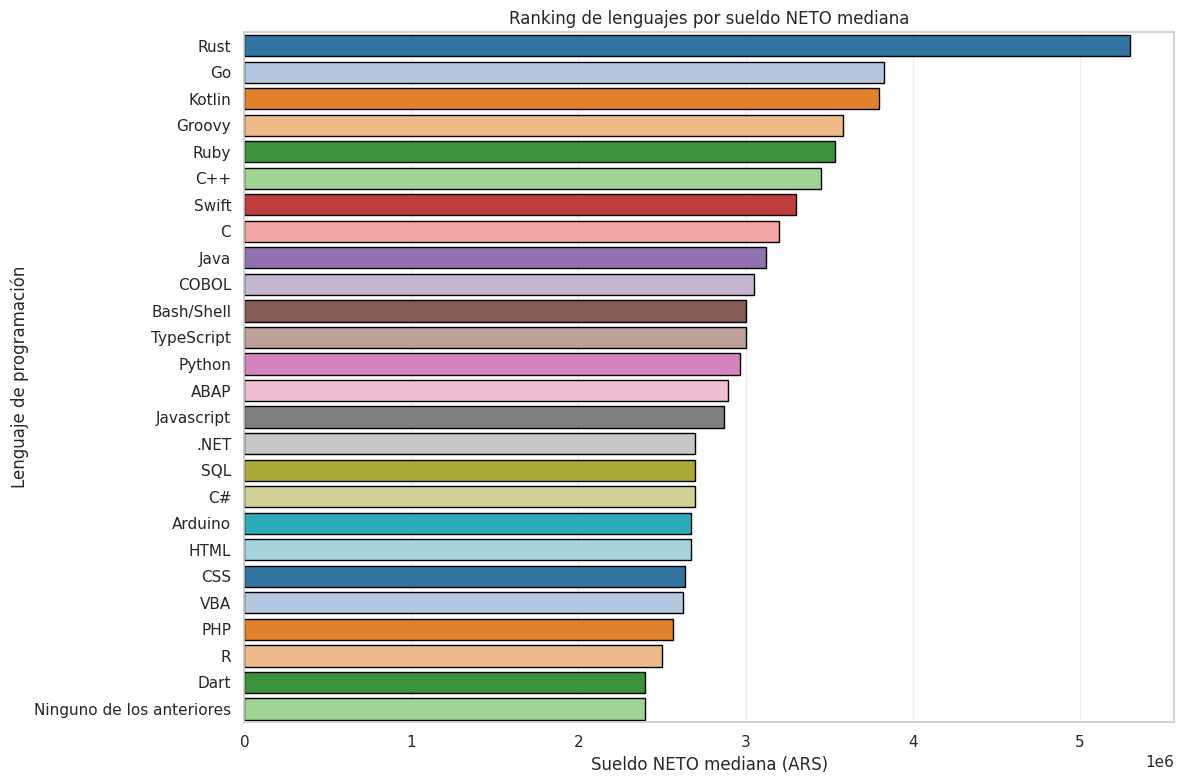

In [ ]:
#Grafico de ranking de lenguajes por sueldo NETO mediana.

fig, ax = plt.subplots(figsize=(12, 8))
seaborn.barplot(
    data=resumen_global.reset_index(),
    x='mediana',
    y='lenguaje',
    ax=ax,
    hue='lenguaje',
    palette='tab20',
    edgecolor='black',
)
ax.set_title('Ranking de lenguajes por sueldo NETO mediana')
ax.set_xlabel('Sueldo NETO mediana (ARS)')
ax.set_ylabel('Lenguaje de programación')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):


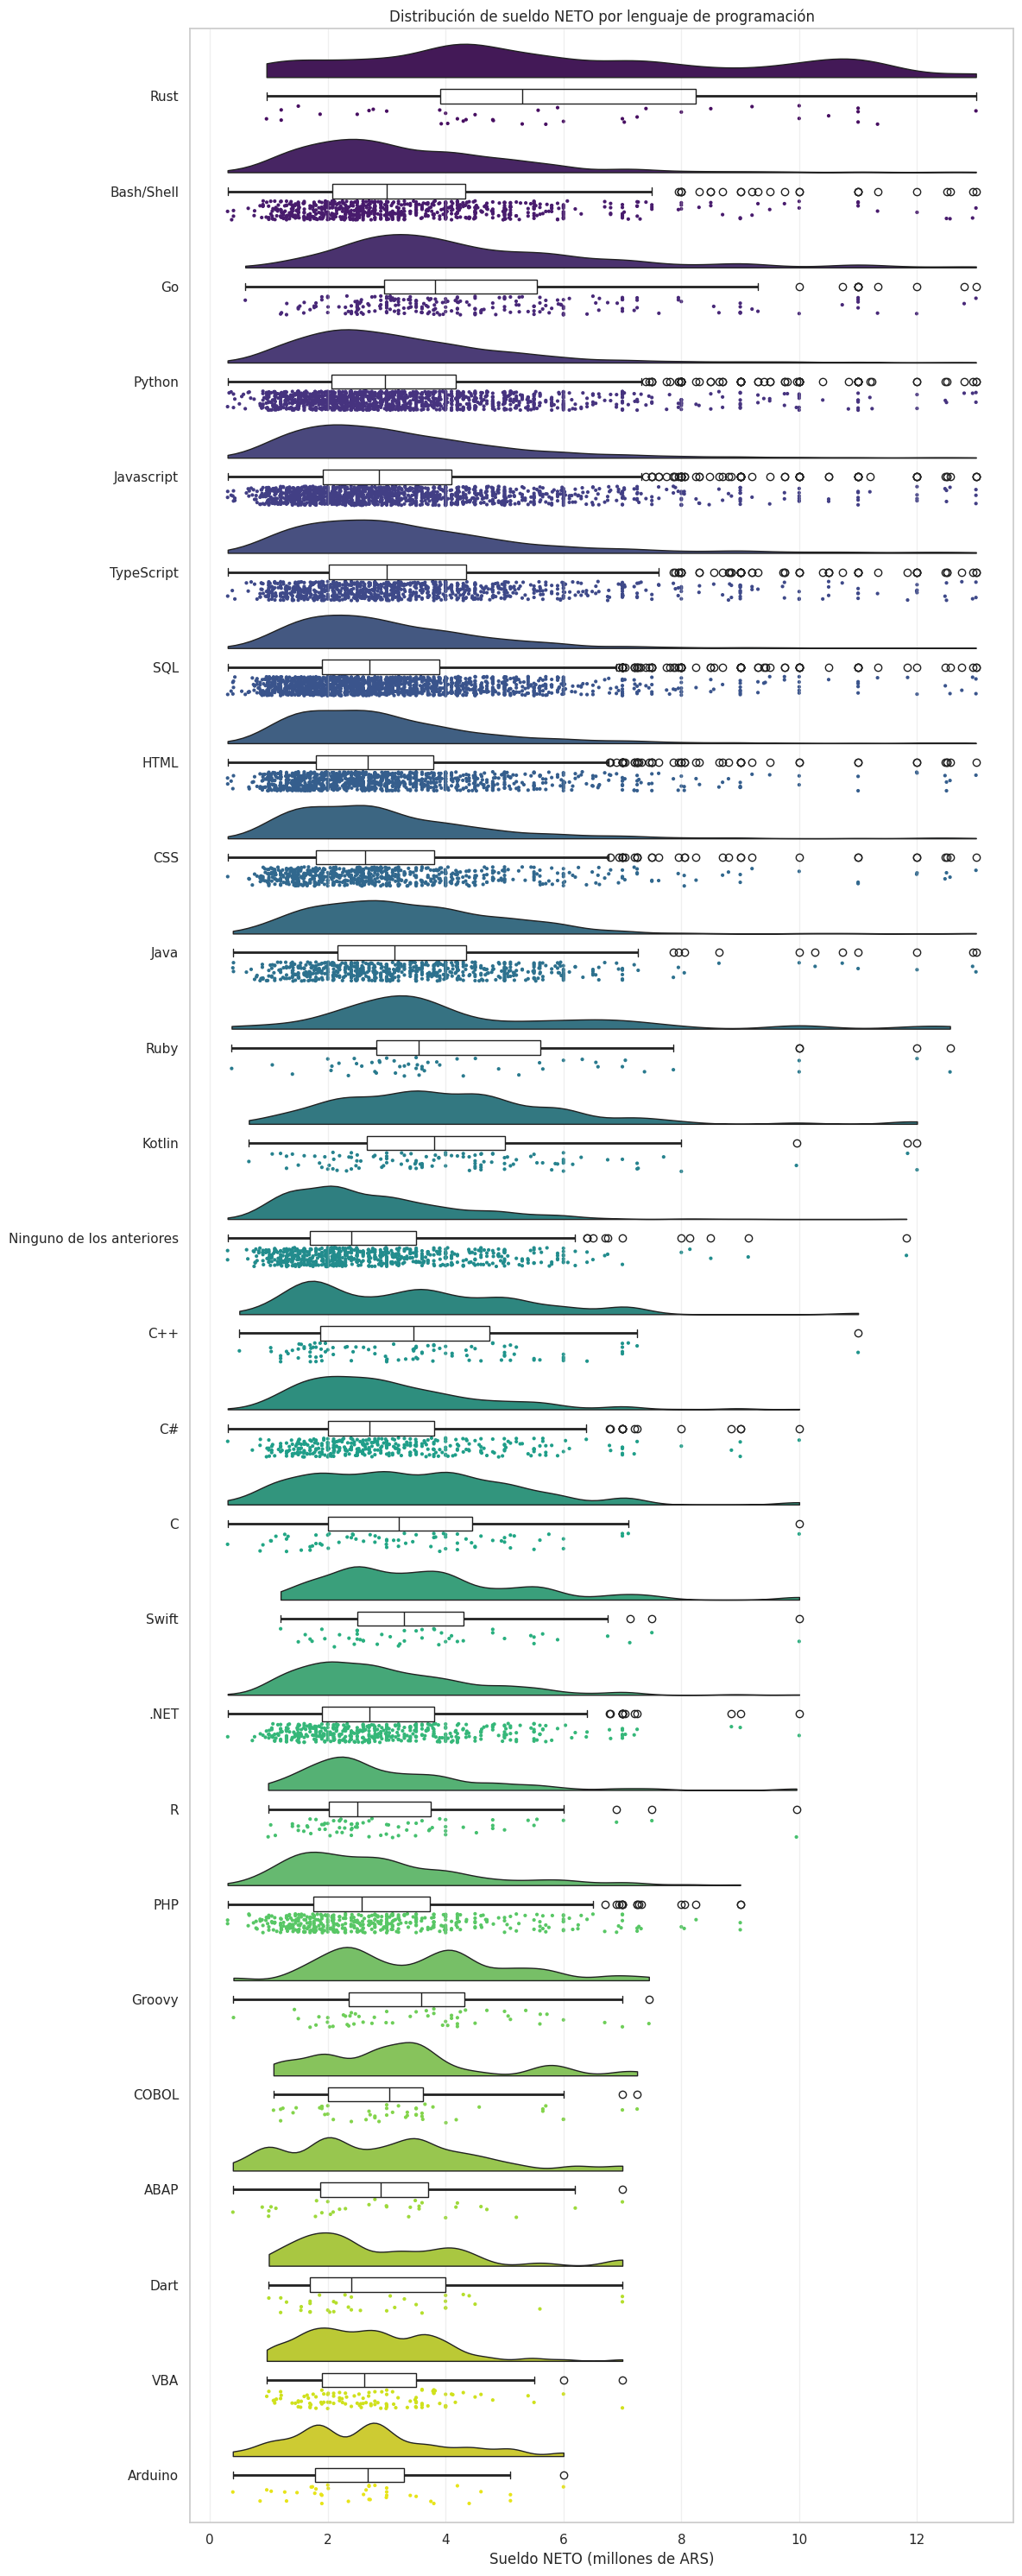

In [ ]:
#Raincloud plot de sueldo NETO por lenguaje de programación.
fig, ax = plt.subplots(figsize=(12, 30))

# 3. Orden de los lenguajes dentro de cada grupo de moneda por sueldo neto mediano
df_rank['lenguaje'] = pd.Categorical(
    df_rank['lenguaje'],
    categories=df_rank.sort_values('salary_monthly_NETO', ascending=False)['lenguaje'].unique(),
    ordered=False
)

ptitprince.RainCloud(
    data=df_rank,
    x='lenguaje',
    y=df_rank['salary_monthly_NETO']/1e6,
    ax=ax,
    hue='lenguaje',
    orient='h',
    palette='viridis',
    move=0.2
)
ax.set_title('Distribución de sueldo NETO por lenguaje de programación')
ax.set_xlabel('Sueldo NETO (millones de ARS)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

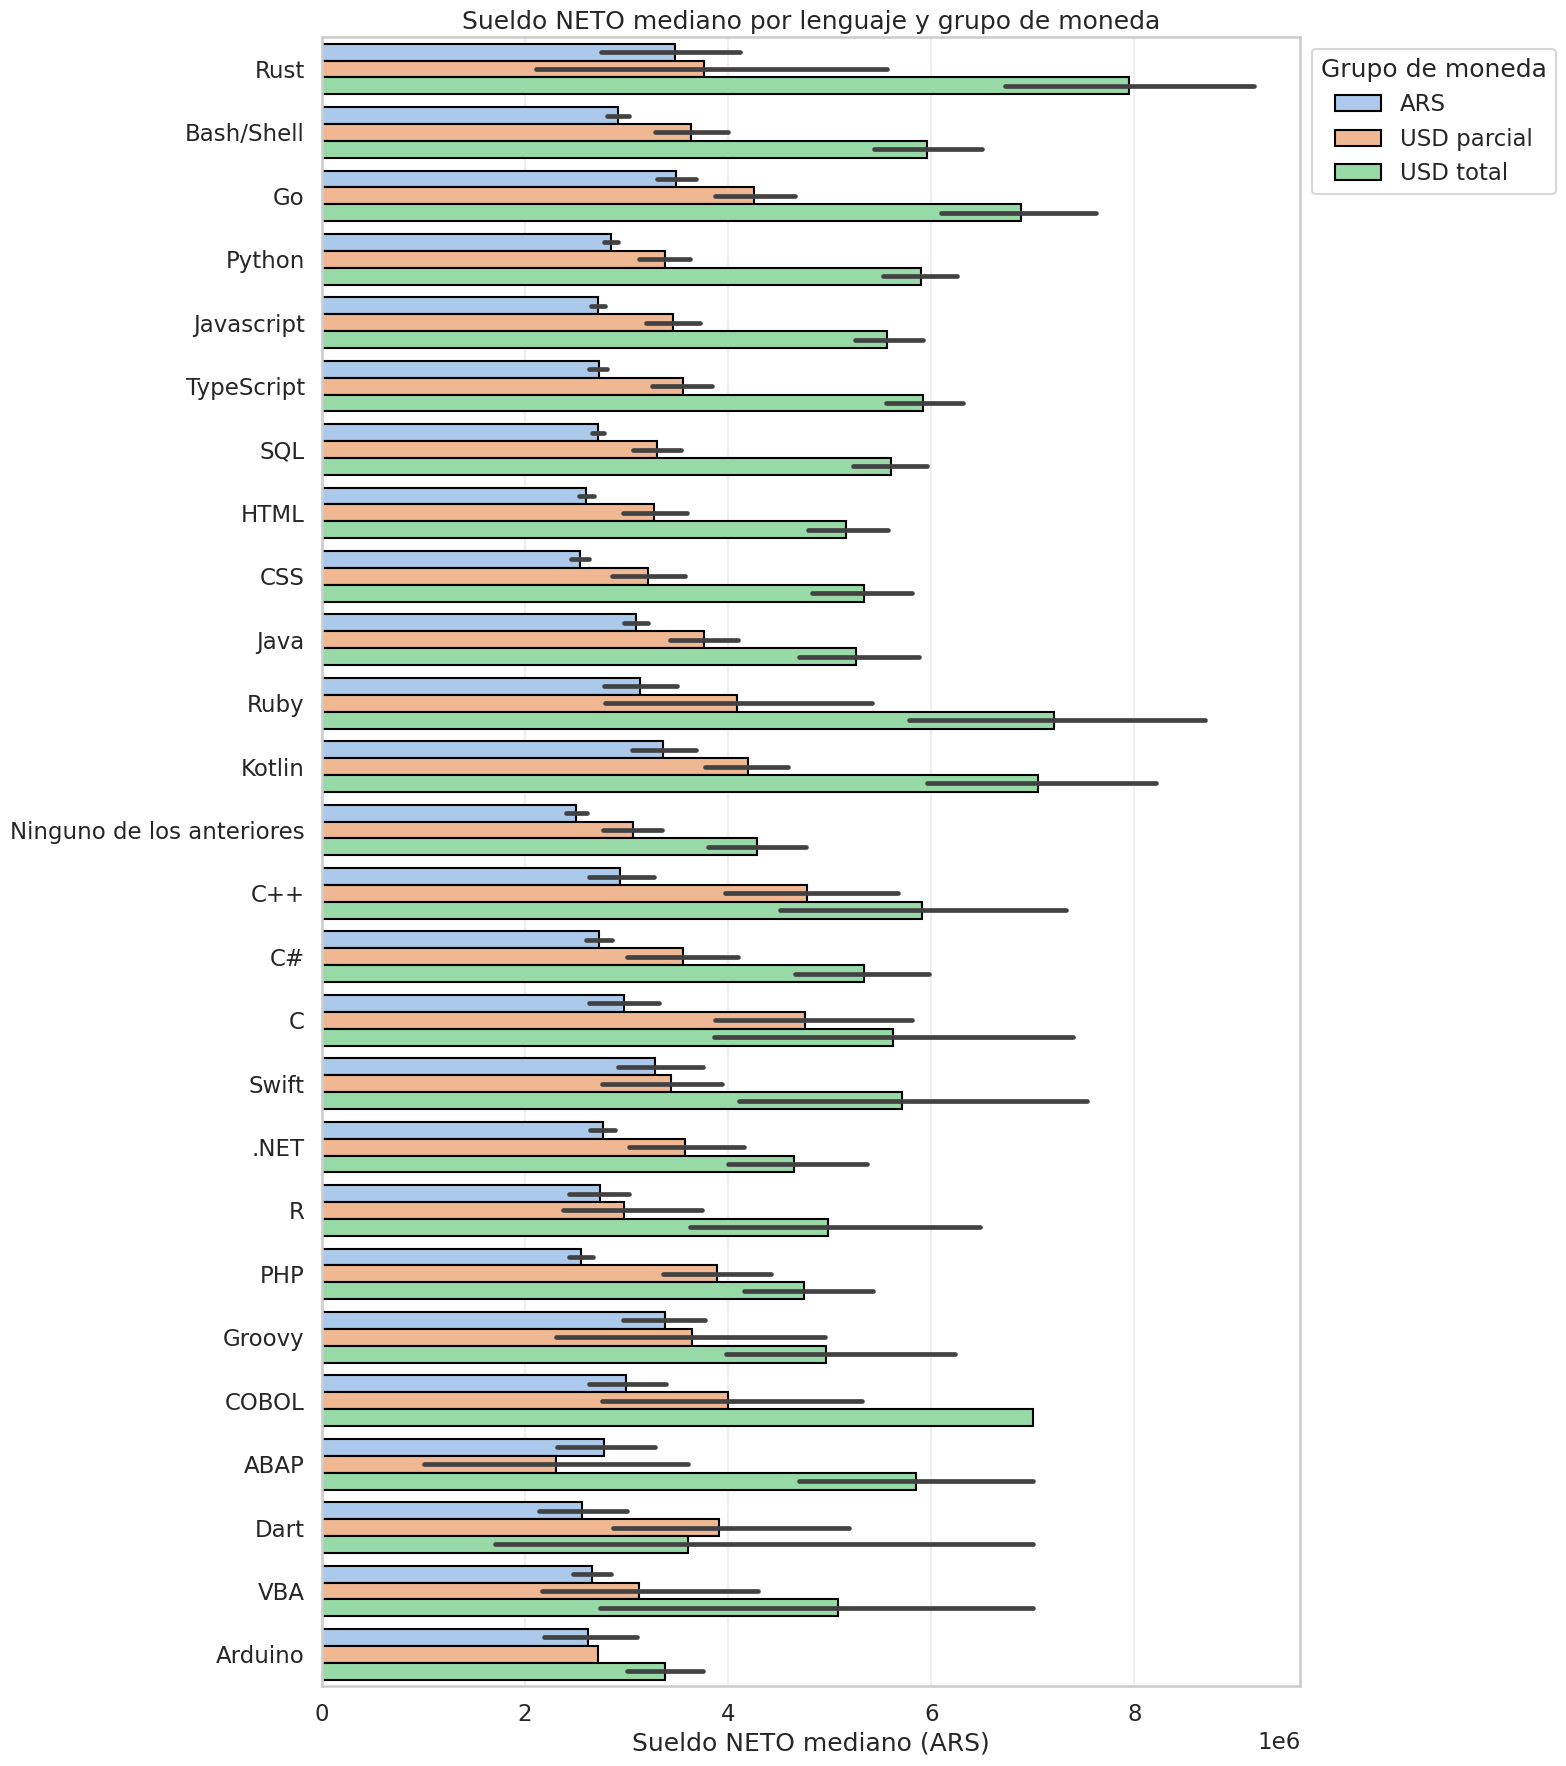

In [ ]:
#Grafico de barras de sueldo neto mediano por lenguaje y grupo de moneda vertical, el orden del grupo de moneda es ARS,USD parcial, USD total y el orden de los lenguajes
#es de mayor a menor sueldo neto mediano dentro de cada grupo de moneda. El gráfico tiene un título, etiquetas en los ejes y una leyenda que indica el grupo de moneda. Se utiliza una paleta de colores para diferenciar los grupos de moneda y se agregan bordes a las barras para mejorar la legibilidad.
fig, ax = plt.subplots(figsize=(16, 18))
seaborn.set_style('whitegrid')

# 2. Definir el orden estricto de los grupos de moneda
orden_moneda = ['ARS', 'USD parcial', 'USD total']

# 3. Orden de los lenguajes dentro de cada grupo de moneda por sueldo neto mediano
df_rank['lenguaje'] = pd.Categorical(
    df_rank['lenguaje'],
    categories=df_rank.sort_values('salary_monthly_NETO', ascending=False)['lenguaje'].unique(),
    ordered=True
)


seaborn.barplot(
    data=df_rank,
    x='salary_monthly_NETO',
    y='lenguaje',
    hue='moneda_grupo',
    hue_order=orden_moneda,
    ax=ax,
    palette='pastel',
    edgecolor='black',
)
ax.set_title('Sueldo NETO mediano por lenguaje y grupo de moneda')
ax.set_xlabel('Sueldo NETO mediano (ARS)')
ax.set_ylabel('')
ax.legend(title='Grupo de moneda', loc='upper left', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.show()

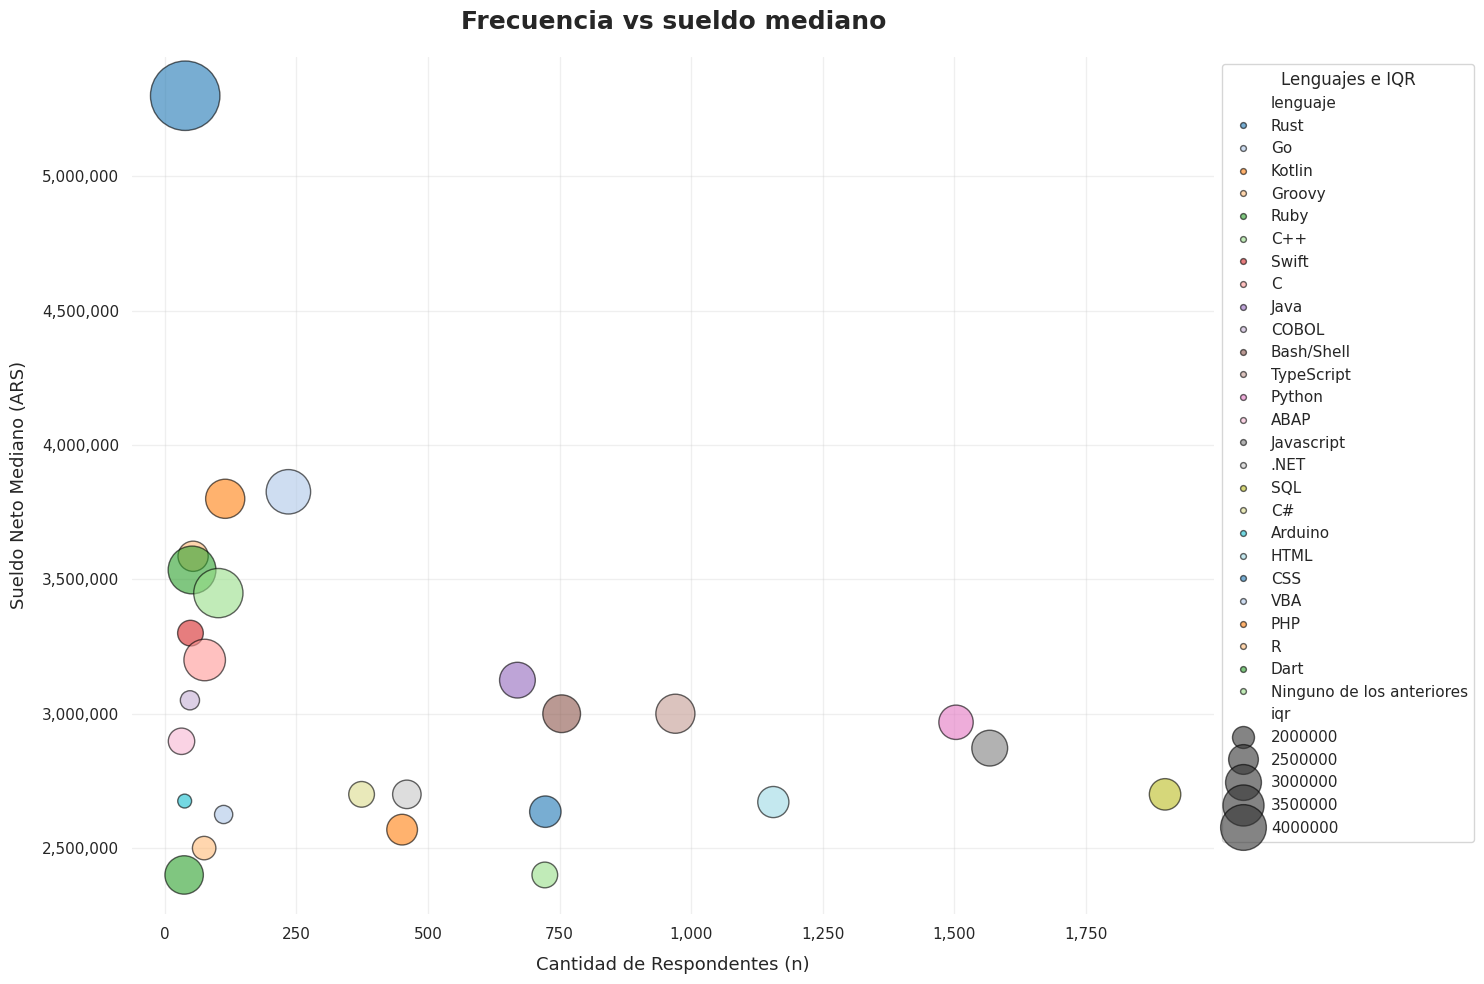

In [ ]:
seaborn.set_theme(style="whitegrid", palette="pastel")

fig, ax = plt.subplots(figsize=(15, 10))

#Ajustamos la transparencia para ver burbujas superpuestas
plot = seaborn.scatterplot(
    data=resumen_global.reset_index(),
    x='n',
    y='mediana',
    size='iqr',
    hue='lenguaje',
    sizes=(100, 2500),      # Rango de tamaños de las burbujas
    alpha=0.6,              # Transparencia
    edgecolor='black',
    linewidth=1,
    palette='tab20',
    ax=ax
)

# Título con jerarquía visual
ax.set_title('Frecuencia vs sueldo mediano', fontsize=18, pad=20, weight='bold')
ax.set_xlabel('Cantidad de Respondentes (n)', fontsize=13, labelpad=10)
ax.set_ylabel('Sueldo Neto Mediano (ARS)', fontsize=13, labelpad=10)

# Mejorar el formato de los ejes (separador de miles)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.get_xaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Leyenda refinada: Separamos la leyenda de Lenguaje de la de Tamaño (IQR)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Lenguajes e IQR', loc='upper left',
          bbox_to_anchor=(1, 1), frameon=True, markerscale=0.7)

# Limpiar bordes innecesarios
seaborn.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## 1.7 Conclusiones del ejercicio 1

Tras el análisis exhaustivo y la depuración de la muestra, se desprenden las siguientes conclusiones principales:

* **Top 3 de Lenguajes:** Los lenguajes con mejor sueldo **NETO mediano** en la muestra analizada son **Rust**, **Go** y **Kotlin**.
* **Liderazgo de Rust:** Rust encabeza el ranking con una mediana de **$5.30 millones de ARS**, situándose un **81% por encima** de la mediana general del conjunto de lenguajes analizados.
* **Variable Respuesta Unificada:** El análisis preliminar confirma que la columna `salary_monthly_NETO` contiene el **total pesificado** para todos los respondentes, lo que valida su uso como una variable coherente para establecer un ranking único.
* **Impacto de la Dolarización:** El orden de los lenguajes se mantiene estable dentro de cada grupo de moneda.
    * Sin embargo, el salto salarial de **ARS** a **USD Total** es superior a casi cualquier diferencia técnica entre lenguajes.
    * Parte del "premio" salarial observado en los lenguajes del tope del ranking se explica por la alta proporción de sueldos dolarizados en esas poblaciones específicas.
* **Estabilidad y Dispersión:** Aplicando el criterio de **Coeficiente de Variación Robusto** con umbral de Tukey, **1 lenguaje (Dart)** fue marcado como atípico en su dispersión.

> Las posiciones de lenguajes marcados como "no estables" deben interpretarse con reserva, ya que su mediana no es representativa del 50% central de sus observaciones debido a la alta heterogeneidad interna.

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

In [ ]:
# ============================================================
# EJERCICIO 2 — Variables, relaciones y condicionalidad
# ============================================================
#
# Ejercicio 2a:  Densidad conjunta con 3 numéricas y 2 categóricas.
# Ejercicio 2b:  Asociación entre sueldo BRUTO y sueldo NETO.
# Ejercicio 2c:  Densidad condicional: sueldo según nivel de estudio.
# Ejercicio 2d:  Densidad conjunta condicional: experiencia vs sueldo
#                coloreada por factor categórico.
#
# El ejercicio 2 trabaja sobre el mismo conjunto de datos filtrado del
# ejercicio 1 (df, N = N_FINAL) a nivel persona: no se desanida la lista
# de lenguajes. Las columnas necesarias ya fueron retenidas en 1.1.


# ============================================================
# 2.0  Selección de variables para el ejercicio 2
# ============================================================

VARS_NUMERICAS = ['salary_monthly_NETO',
                  'profile_years_experience',
                  'profile_age']
VARS_CATEGORICAS = ['work_seniority', 'profile_gender']

seleccion_ej2 = pd.DataFrame({
    'variable': VARS_NUMERICAS + VARS_CATEGORICAS,
    'tipo': (['numérica'] * 3) + (['categórica'] * 2),
    'rol en el ejercicio 2': [
        'variable respuesta principal',
        'variable numérica de control (años de experiencia)',
        'variable numérica de control (edad del respondente)',
        'factor categórico: nivel de seniority',
        'factor categórico: identidad de género',
    ],
})
mostrar('2.0  Variables seleccionadas para el ejercicio 2', seleccion_ej2)


# ============================================================
# 2.0.1  Filtro local de edad biológica (sólo ejercicio 2)
# ============================================================
# La columna profile_age contiene algunos valores implausibles
# (por ejemplo 999 años) que no fueron removidos en los filtros
# F1-F5 del ejercicio 1, porque allí la edad no participaba del
# análisis. Para el ejercicio 2 —donde sí se usa la edad como
# variable numérica— se aplica un filtro LOCAL al tramo
# [15, 80] años, que es el rango laboralmente plausible.
#
# IMPORTANTE: este filtro NO se propaga al ejercicio 1. El
# ranking de lenguajes (sección 1) ya fue calculado sobre df
# completo. Aquí se crea un DataFrame separado df_ej2 para no
# alterar el flujo del ejercicio 1.
EDAD_MIN_EJ2 = 15
EDAD_MAX_EJ2 = 80

mask_edad_ej2 = df['profile_age'].between(EDAD_MIN_EJ2, EDAD_MAX_EJ2)
n_antes_ej2 = len(df)
df_ej2 = df[mask_edad_ej2].copy()
n_despues_ej2 = len(df_ej2)
n_descartados_ej2 = n_antes_ej2 - n_despues_ej2

edades_descartadas = (
    df.loc[~mask_edad_ej2, 'profile_age']
    .dropna().sort_values(ascending=False).unique().tolist()
)
filtro_edad_ej2 = pd.DataFrame({
    'métrica': [
        'N antes del filtro (N_FINAL del ej 1)',
        'tramo retenido (años)',
        'N después del filtro',
        'filas descartadas',
        'ejemplos de edades descartadas',
        'alcance del filtro',
    ],
    'valor': [
        n_antes_ej2,
        f'[{EDAD_MIN_EJ2}, {EDAD_MAX_EJ2}]',
        n_despues_ej2,
        n_descartados_ej2,
        ', '.join(str(int(x)) for x in edades_descartadas[:6])
        if edades_descartadas else '—',
        'sólo ejercicio 2 (no afecta al ejercicio 1)',
    ],
})
mostrar('2.0.1  Filtro local de edad biológica (sólo ej 2)',
        filtro_edad_ej2)


━━━ 2.0  Variables seleccionadas para el ejercicio 2 ━━━━━━━━━━━━━━━━━━━━━━
                   variable        tipo                                rol en el ejercicio 2
0       salary_monthly_NETO    numérica                         variable respuesta principal
1  profile_years_experience    numérica   variable numérica de control (años de experiencia)
2               profile_age    numérica  variable numérica de control (edad del respondente)
3            work_seniority  categórica                factor categórico: nivel de seniority
4            profile_gender  categórica               factor categórico: identidad de género

━━━ 2.0.1  Filtro local de edad biológica (sólo ej 2) ━━━━━━━━━━━━━━━━━━━━━
                                 métrica                                        valor
0  N antes del filtro (N_FINAL del ej 1)                                         4207
1                  tramo retenido (años)                                     [15, 80]
2                   N después 

# Ejercicio 2 — Variables, relaciones y condicionalidad

## 2.0 Selección de variables

El análisis se realiza sobre el mismo conjunto de datos consolidado y filtrado en el Ejercicio 1 ($N = 4.207$), manteniendo la integridad de la muestra a nivel persona.

Las variables seleccionadas para este estudio son:

### Variables Numéricas
* **`salary_monthly_NETO`**: Variable respuesta (total pesificado).
* **`profile_years_experience`**: Años de experiencia profesional.
* **`profile_age`**: Edad del respondente.

### Variables Categóricas
* **`work_seniority`**: Nivel de seniority (Junior, Semi-Senior, Senior).
* **`profile_gender`**: Identidad de género declarada.

---

> **Nota Metodológica:** Para este ejercicio **no se desanida** la lista de lenguajes. Cada fila representa a un único respondente con su perfil completo de variables demográficas y laborales, lo que permite estudiar correlaciones y brechas de forma directa.

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




In [ ]:
# ============================================================
# 2.a  Densidad conjunta (3 numéricas + 2 categóricas)
# ============================================================

# --- 2.a.1  Estadísticos descriptivos de las 3 numéricas ---
describe_num = (
    df_ej2[VARS_NUMERICAS]
    .describe(percentiles=[.10, .25, .50, .75, .90])
    .round(2)
)
mostrar('2.a.1  Estadísticos descriptivos de las variables numéricas',
        describe_num)

# --- 2.a.2 y 2.a.3  Matrices de correlación ---
corr_pearson = df_ej2[VARS_NUMERICAS].corr(method='pearson').round(3)
corr_spearman = df_ej2[VARS_NUMERICAS].corr(method='spearman').round(3)
mostrar('2.a.2  Correlación de Pearson entre numéricas', corr_pearson)
mostrar('2.a.3  Correlación de Spearman entre numéricas', corr_spearman)

# --- 2.a.4  Distribución de las variables categóricas ---
seniority_counts = df['work_seniority'].value_counts().to_frame('n')
seniority_counts['pct'] = (100 * seniority_counts['n'] / len(df)).round(2)
mostrar('2.a.4  Distribución de work_seniority', seniority_counts)

gender_counts = df['profile_gender'].value_counts(dropna=False).to_frame('n')
gender_counts['pct'] = (100 * gender_counts['n'] / len(df)).round(2)
mostrar('2.a.5  Distribución de profile_gender', gender_counts)

# --- 2.a.6  Contingencia seniority × gender ---
contingencia = pd.crosstab(df['work_seniority'], df['profile_gender'])
mostrar('2.a.6  Contingencia work_seniority × profile_gender',
        contingencia)


━━━ 2.a.1  Estadísticos descriptivos de las variables numéricas ━━━━━━━━━━━
       salary_monthly_NETO  profile_years_experience  profile_age
count              4204.00                   4204.00       4204.0
mean            3148101.68                      9.77         36.9
std             1813217.20                      8.01          8.8
min              300000.00                      0.00         16.0
10%             1350000.00                      2.00         26.0
25%             1900000.00                      4.00         30.0
50%             2750000.00                      7.00         36.0
75%             3952546.75                     15.00         42.0
90%             5357000.00                     20.00         49.0
max            13000000.00                     48.00         75.0

━━━ 2.a.2  Correlación de Pearson entre numéricas ━━━━━━━━━━━━━━━━━━━━━━━━━
                          salary_monthly_NETO  profile_years_experience  profile_age
salary_monthly_NETO                

## 2. Densidad conjunta (3 numéricas + 2 categóricas)

En esta etapa se analizan las variables de forma individual (distribuciones marginales) para luego estudiar su comportamiento conjunto. El objetivo es entender cómo la experiencia y la edad se entrelazan con la remuneración neta.

### Estadísticos Descriptivos de Variables Numéricas

| Métrica | `salary_monthly_NETO` | `profile_years_experience` | `profile_age` |
| :--- | :---: | :---: | :---: |
|**count**|4.204|4.204|4.204|
|**mean**|3148101.68|9.77|36.9
|**std**|1813217.20|8.01|8.8|
|**min**|300000.00|0.00|16.0|
|**10%**|1350000.00|2.00|26.0|
|**25%**|1900000.00|4.00|30.0|
|**50%**|2750000.00|7.00|36.0|
|**75%**|3952546.75|15.00|42.0|
|**90%**|5357000.00|20.00|49.0|
|**max**|13000000.00|48.00|75.0|

---

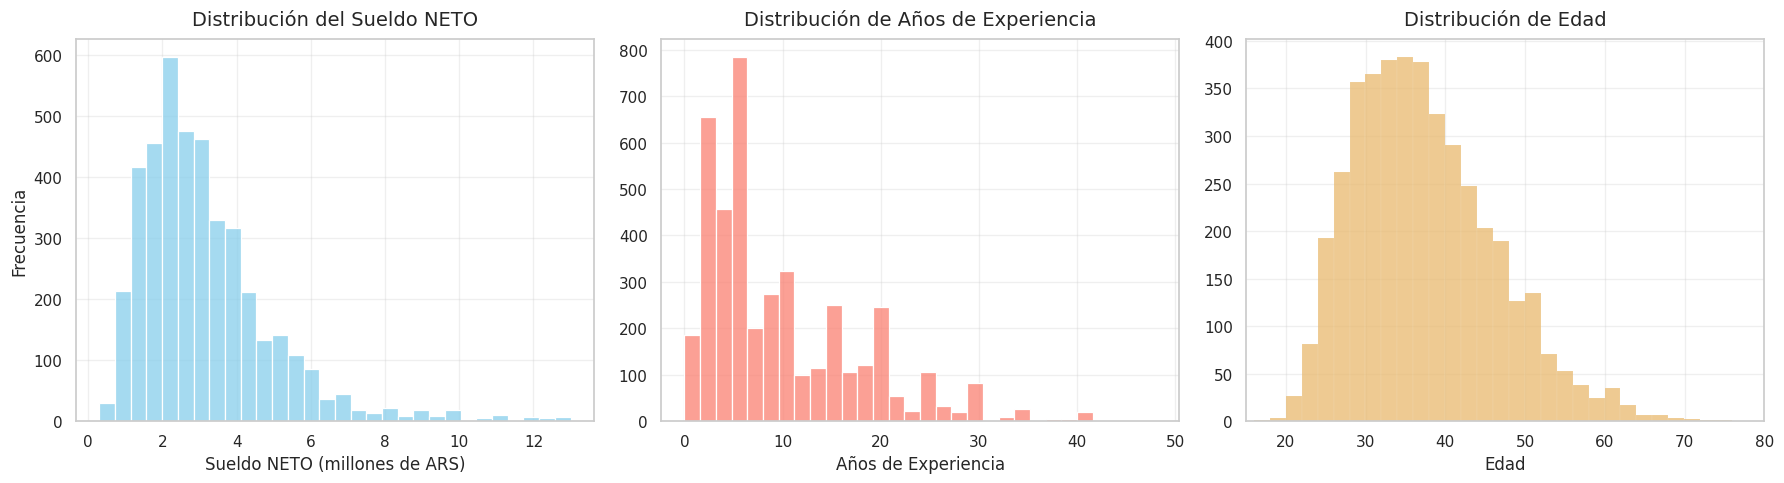

In [ ]:
# 3 graficos histplot de frecuencia de sueldo neto, de años de experiencia y de edad.
seaborn.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Histograma de sueldo neto
seaborn.histplot(df['salary_monthly_NETO']/1e6, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Sueldo NETO', fontsize=14, pad=10)
axes[0].set_xlabel('Sueldo NETO (millones de ARS)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
# Histograma de años de experiencia
seaborn.histplot(df['profile_years_experience'], bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Años de Experiencia', fontsize=14, pad=10)
axes[1].set_xlabel('Años de Experiencia', fontsize=12)
axes[1].set_ylabel('')
# Histograma de edad
seaborn.histplot(df['profile_age'],binwidth=2,color='#e9b96e',edgecolor='white', ax=axes[2])
axes[2].set_title('Distribución de Edad', fontsize=14, pad=10)
axes[2].set_xlabel('Edad', fontsize=12)
axes[2].set_xlim(15, 80)  # Ajustamos el rango de edad para mejor visualización
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

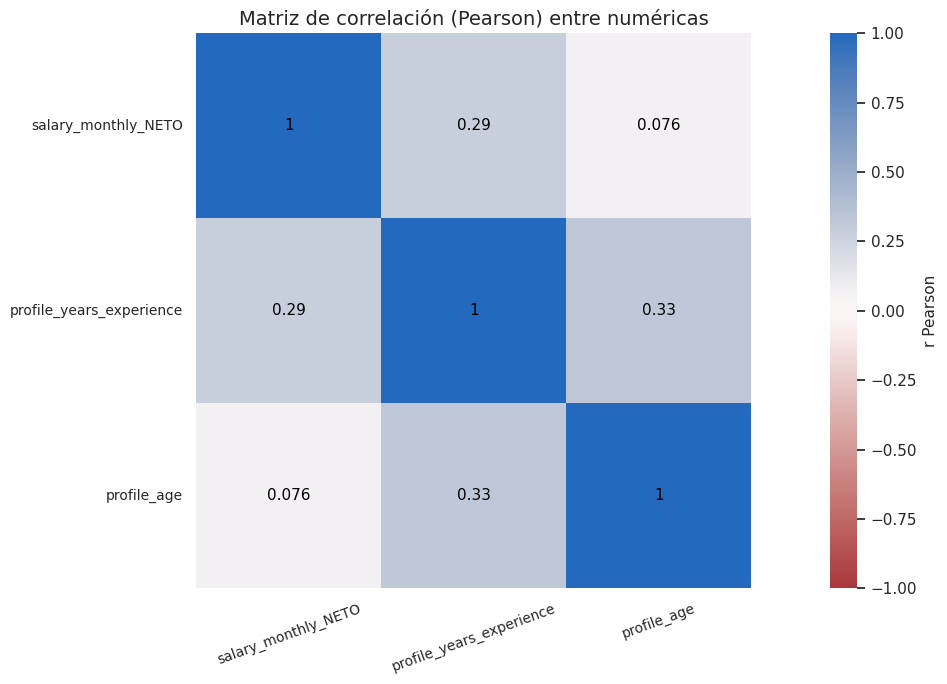

In [ ]:
cols_interes = ['salary_monthly_NETO', 'profile_years_experience', 'profile_age']
df_numericas = df[cols_interes].copy()

matriz_corr = df_numericas.dropna().corr(method='pearson').round(3)

seaborn.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(16, 7))

heatmap = seaborn.heatmap(
    matriz_corr,
    annot=True,
    cmap="vlag_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={'size': 11, 'color': 'black'}
)

# 5. Personalización de Títulos y Etiquetas
# Título superior
ax.set_title('Matriz de correlación (Pearson) entre numéricas', fontsize=14)

# Etiquetas del eje Y (izquierda)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Etiquetas del eje X (inferior) con la rotación exacta de la foto
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, fontsize=10)

# 6. Personalizar la leyenda (Color Bar)
heatmap.collections[0].colorbar.set_label('r Pearson', size=11)

plt.tight_layout()
plt.show()

### 2.a Análisis Categórico: Seniority y Género

En el plano categórico, se analiza la distribución del nivel de **seniority** y del **grupo de género**. El objetivo es observar la composición de la muestra antes de cruzar estas variables con los niveles salariales.

#### Agrupación Analítica de Género
Para el análisis de la variable `profile_gender`, se definen tres grupos analíticos (explicados en detalle en la sección **2.d**). Esta segmentación permite representar a todos los respondentes del formulario sin comprometer la legibilidad estadística:

* **Hombre Cis**
* **Mujer Cis**
* **Diversidades**: Este grupo agrupa identidades con baja cobertura muestral individual (personas Trans, No Binarias, entre otras).

> **Justificación Metodológica:** Esta agrupación garantiza que todas las identidades estén representadas en el análisis, evitando la dispersión en "barras minúsculas" que dificultarían la visualización de tendencias y la comparación de medianas.

#### Distribución de Seniority
Se mantiene la clasificación original del dataset para evaluar cómo se distribuye la muestra entre perfiles:
1. **Junior**
2. **Semi-Senior**
3. **Senior**


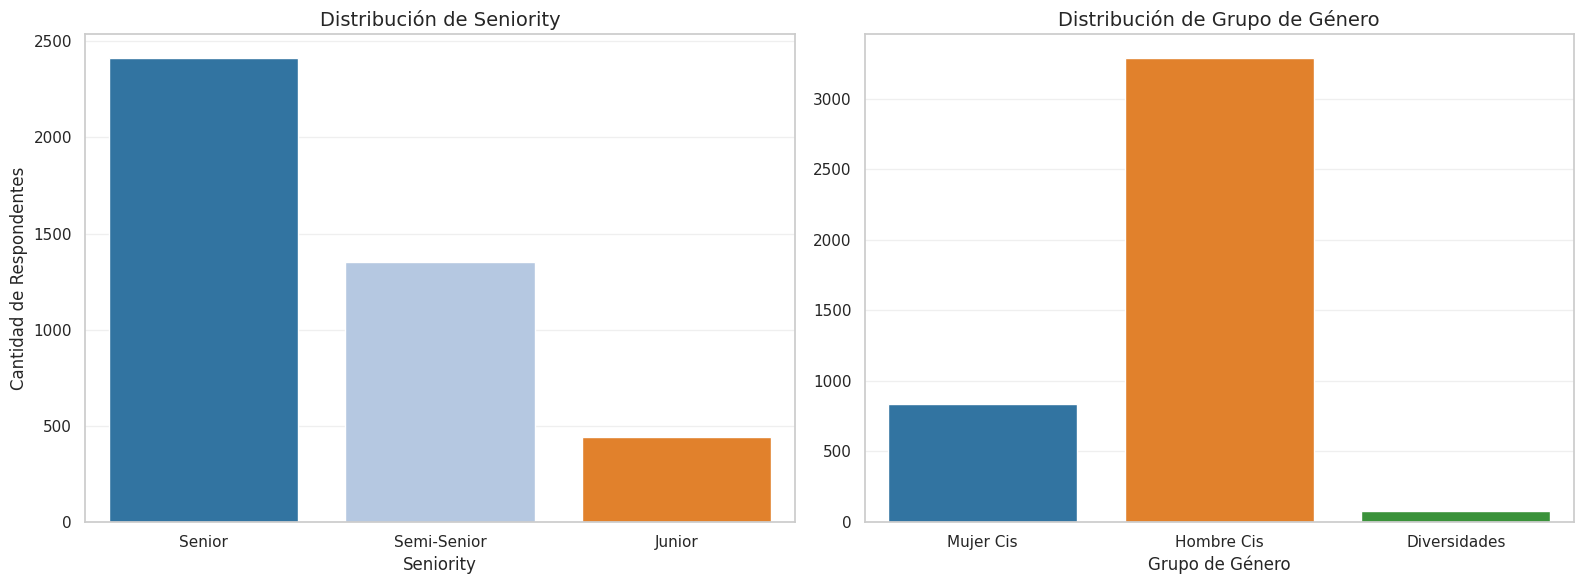

In [ ]:
#countplot de las variables categoricas seniority y grupo de genero.

#Agrupar todos los grupos de genero que no sean 'Hombre Cis' o 'Mujer Cis' en una categoría 'Diversidades' para mejorar la visualización.
df_gender = df.copy()
df_gender['genero_grupo'] = df_gender['profile_gender'].apply(lambda x: x if x in ['Hombre Cis', 'Mujer Cis'] else 'Diversidades')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
seaborn.countplot(data=df, x='work_seniority',hue='work_seniority', ax=axes[0], palette='tab20')
axes[0].set_title('Distribución de Seniority', fontsize=14)
axes[0].set_xlabel('Seniority', fontsize=12)
axes[0].set_ylabel('Cantidad de Respondentes', fontsize=12)
seaborn.countplot(data=df_gender, x='genero_grupo',hue='genero_grupo', ax=axes[1], palette='tab10')
axes[1].set_title('Distribución de Grupo de Género', fontsize=14)
axes[1].set_xlabel('Grupo de Género', fontsize=12)
axes[1].set_ylabel('', fontsize=12)
plt.tight_layout()
plt.show()


## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



In [ ]:
# ============================================================
# 2.b  Asociación: correlación Bruto vs Neto
# ============================================================

bn = df[['salary_monthly_BRUTO', 'salary_monthly_NETO']].dropna()
bn = bn[(bn['salary_monthly_BRUTO'] > 0) & (bn['salary_monthly_NETO'] > 0)]
bn['ratio_neto_bruto'] = bn['salary_monthly_NETO'] / bn['salary_monthly_BRUTO']

p_bruto_neto = bn[['salary_monthly_BRUTO', 'salary_monthly_NETO']].corr(
    method='pearson').iloc[0, 1]
s_bruto_neto = bn[['salary_monthly_BRUTO', 'salary_monthly_NETO']].corr(
    method='spearman').iloc[0, 1]

ratio_mediana = bn['ratio_neto_bruto'].median()
ratio_media = bn['ratio_neto_bruto'].mean()
ratio_q1 = bn['ratio_neto_bruto'].quantile(.25)
ratio_q3 = bn['ratio_neto_bruto'].quantile(.75)

asociacion_bruto_neto = pd.DataFrame({
    'métrica': [
        'observaciones válidas',
        'correlación de Pearson',
        'correlación de Spearman',
        'ratio NETO/BRUTO mediano',
        'ratio NETO/BRUTO medio',
        'ratio NETO/BRUTO Q1',
        'ratio NETO/BRUTO Q3',
    ],
    'valor': [
        len(bn),
        round(p_bruto_neto, 4),
        round(s_bruto_neto, 4),
        round(ratio_mediana, 4),
        round(ratio_media, 4),
        round(ratio_q1, 4),
        round(ratio_q3, 4),
    ],
})
mostrar('2.b.1  Asociación entre sueldo BRUTO y sueldo NETO',
        asociacion_bruto_neto)


━━━ 2.b.1  Asociación entre sueldo BRUTO y sueldo NETO ━━━━━━━━━━━━━━━━━━━━
                    métrica      valor
0     observaciones válidas  4207.0000
1    correlación de Pearson     0.9472
2   correlación de Spearman     0.9543
3  ratio NETO/BRUTO mediano     0.8333
4    ratio NETO/BRUTO medio     0.8797
5       ratio NETO/BRUTO Q1     0.8000
6       ratio NETO/BRUTO Q3     0.8936


In [ ]:
# --- 2.b.2  Regresión lineal neto = a · bruto + b ---
coef_reg = numpy.polyfit(bn['salary_monthly_BRUTO'],
                      bn['salary_monthly_NETO'], 1)
regresion_tabla = pd.DataFrame({
    'parámetro': ['pendiente (a)', 'ordenada al origen (b)'],
    'valor':     [round(coef_reg[0], 4),
                  round(coef_reg[1], 2)],
    'interpretación': [
        'ARS netos observados por cada ARS bruto',
        'componente fija en ARS (tiende a cero en el caso ideal)',
    ],
})
mostrar('2.b.2  Regresión lineal NETO = a · BRUTO + b', regresion_tabla)


━━━ 2.b.2  Regresión lineal NETO = a · BRUTO + b ━━━━━━━━━━━━━━━━━━━━━━━━━━
                parámetro        valor                                           interpretación
0           pendiente (a)       0.8075                  ARS netos observados por cada ARS bruto
1  ordenada al origen (b)  138394.6000  componente fija en ARS (tiende a cero en el caso ideal)


In [ ]:
# --- 2.b.3  Columna derivada DESCUENTOS = BRUTO - NETO ---
# Siguiendo el práctico de la clase 03, se construye una columna
# derivada con los descuentos mensuales. Permite caracterizar la
# redundancia entre BRUTO y NETO: si los descuentos son aproximadamente
# proporcionales al bruto, la información de BRUTO queda contenida en
# NETO salvo un factor multiplicativo.
bn['descuentos'] = bn['salary_monthly_BRUTO'] - bn['salary_monthly_NETO']
bn['descuentos_pct'] = 100 * bn['descuentos'] / bn['salary_monthly_BRUTO']

descuentos_resumen = pd.DataFrame({
    'métrica': [
        'descuentos mensuales medianos (ARS)',
        'descuentos mensuales medios (ARS)',
        'descuento relativo mediano (% del BRUTO)',
        'descuento relativo medio (% del BRUTO)',
        'descuento relativo Q1 (%)',
        'descuento relativo Q3 (%)',
    ],
    'valor': [
        fmt_ars(bn['descuentos'].median()),
        fmt_ars(bn['descuentos'].mean()),
        f'{bn["descuentos_pct"].median():.2f} %',
        f'{bn["descuentos_pct"].mean():.2f} %',
        f'{bn["descuentos_pct"].quantile(.25):.2f} %',
        f'{bn["descuentos_pct"].quantile(.75):.2f} %',
    ],
})
mostrar('2.b.3  Columna derivada DESCUENTOS = BRUTO − NETO',
        descuentos_resumen)


━━━ 2.b.3  Columna derivada DESCUENTOS = BRUTO − NETO ━━━━━━━━━━━━━━━━━━━━━
                                    métrica    valor
0       descuentos mensuales medianos (ARS)  456.000
1         descuentos mensuales medios (ARS)  579.521
2  descuento relativo mediano (% del BRUTO)  16.67 %
3    descuento relativo medio (% del BRUTO)  12.03 %
4                 descuento relativo Q1 (%)  10.64 %
5                 descuento relativo Q3 (%)  20.00 %


In [ ]:
# --- 2.b.4  Respuesta a la pregunta implícita de la consigna ---
#
# La consigna pregunta: "Necesitamos decidir si sacar o no la columna
# de salario bruto. Para hacer la encuesta más simple. ¿Existe una
# correlación entre el salario bruto y el neto?"
#
# Se construye una respuesta basada en lo observado en esta muestra,
# manteniendo el carácter descriptivo (no se extrapola a la población
# general).
respuesta_2b = pd.DataFrame({
    'criterio': [
        'correlación muestral Pearson',
        'correlación muestral Spearman',
        'estabilidad del ratio NETO/BRUTO (IQR)',
        'información no redundante en BRUTO',
        'recomendación sobre la columna BRUTO',
    ],
    'observación': [
        f'{p_bruto_neto:.3f} (muy cercana a 1 en esta muestra)',
        f'{s_bruto_neto:.3f} (muy cercana a 1 en esta muestra)',
        f'estrecha: el 50 % central del ratio cae entre '
        f'{bn["descuentos_pct"].quantile(.25):.1f} % y '
        f'{bn["descuentos_pct"].quantile(.75):.1f} % de descuentos',
        'baja, una vez conocida NETO',
        'dada la observación en esta muestra y bajo los filtros '
        'aplicados, la columna BRUTO puede considerarse altamente '
        'redundante con NETO y podría omitirse del formulario sin '
        'pérdida sustancial para este tipo de análisis descriptivo.',
    ],
})
mostrar('2.b.4  Respuesta a la pregunta implícita sobre BRUTO',
        respuesta_2b)


━━━ 2.b.4  Respuesta a la pregunta implícita sobre BRUTO ━━━━━━━━━━━━━━━━━━
                                 criterio                                                                                                                                                                                                                          observación
0            correlación muestral Pearson                                                                                                                                                                                              0.947 (muy cercana a 1 en esta muestra)
1           correlación muestral Spearman                                                                                                                                                                                              0.954 (muy cercana a 1 en esta muestra)
2  estabilidad del ratio NETO/BRUTO (IQR)                                                                     

### 2.b Relación entre Sueldo Bruto y Neto

Se estudia la asociación entre el sueldo **BRUTO** y el sueldo **NETO** declarados. Más allá de la correlación simple, se construye la variable derivada:
$$\text{DESCUENTOS} = \text{BRUTO} - \text{NETO}$$

Esta métrica permite caracterizar el margen existente entre ambas variables una vez descontada la parte lineal. Para este análisis, se utilizan **4.207 observaciones válidas** (registros con ambos valores presentes y estrictamente positivos tras aplicar los filtros F1 a F5).

#### Métricas de Asociación y Ajuste

| Indicador | Valor |
| :--- | :--- |
| **Correlación de Pearson** | 0.947 |
| **Correlación de Spearman** | 0.954 |
| **Ratio NETO/BRUTO (Mediano)** | **0.833** |
| **Descuento relativo mediano** | **16.67 %** |

---

#### Análisis de Regresión Lineal
La recta ajustada por mínimos cuadrados ordinarios (OLS) arroja los siguientes parámetros:
* **Pendiente muestral:** $0.835$ (representa los ARS netos observados por cada ARS bruto).
* **Ordenada al origen:** $\$ 138.395$.

> En esta muestra el descuento relativo mediano es del **16.67%**, con un rango intercuartil entre **10.64%** y **20.00%**.

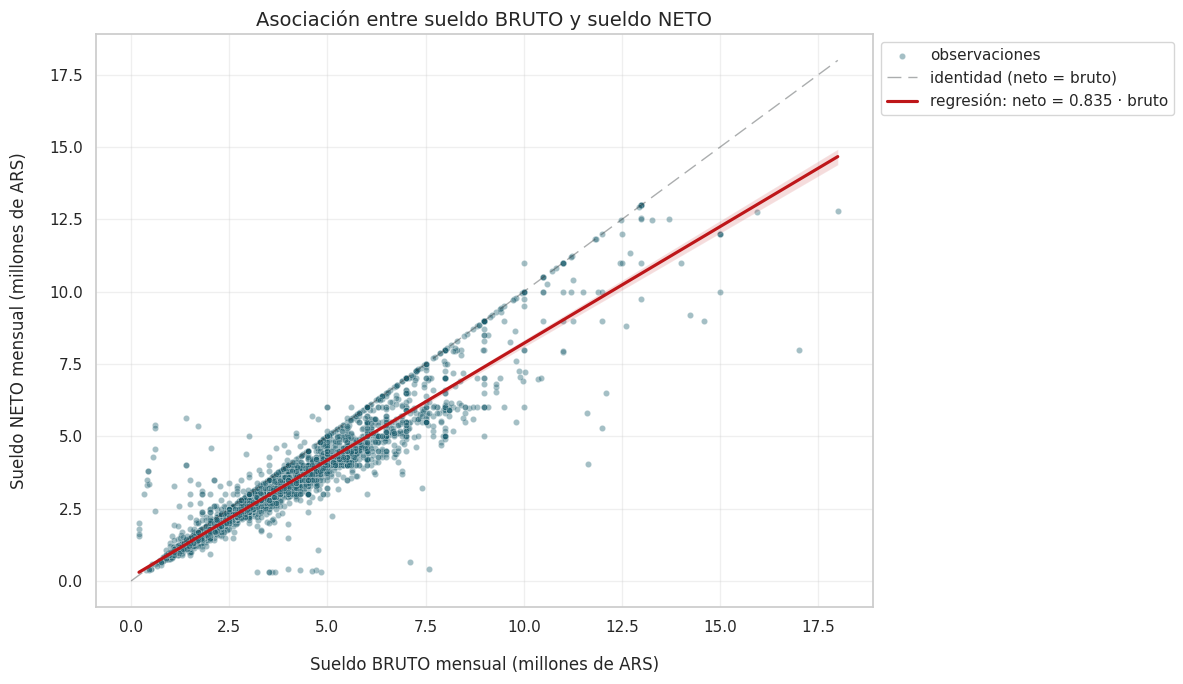

In [ ]:
# Convertimos a millones para el gráfico
x = df['salary_monthly_BRUTO'] / 1e6
y = df['salary_monthly_NETO'] / 1e6

# Cálculo de la regresión lineal
model = LinearRegression(fit_intercept=False)
model.fit(x.values.reshape(-1, 1), y)
slope = model.coef_[0]

seaborn.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Hacemos el scatterplot.
seaborn.scatterplot(
    x=x, y=y,
    alpha=0.4,
    s=20,
    color='#1d5f6f',
    label='observaciones'
)

# Dibujamos la linea de la identidad.
max_val = max(x.max(), y.max())
ax.plot([0, max_val], [0, max_val],
        color='#2e3436', linestyle=(0, (10, 5)), linewidth=1, alpha=0.4,
        label='identidad (neto = bruto)')

# Dibujamos la regresión lineal
seaborn.regplot(
    x=x, y=y,
    scatter=False,
    color='#be1619',
    label=f'regresión: neto = {slope:.3f} · bruto',
    ax=ax
)

ax.set_title('Asociación entre sueldo BRUTO y sueldo NETO', fontsize=14)
ax.set_xlabel('Sueldo BRUTO mensual (millones de ARS)', fontsize=12, labelpad=15)
ax.set_ylabel('Sueldo NETO mensual (millones de ARS)', fontsize=12, labelpad=15)

# Leyenda externa
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

### ¿Conviene simplificar el formulario omitiendo el Sueldo BRUTO?

Una de las preguntas que motiva este sub-ejercicio es si la encuesta sysarmy podría simplificarse eliminando la columna de sueldo bruto, que actualmente duplica información que parece derivable del sueldo neto. Los datos de esta muestra dan una respuesta razonablemente clara:

* Las correlaciones muestrales Pearson (0.947) y Spearman (0.954) son muy cercanas a 1.
* El ratio NETO/BRUTO muestra una estructura estable, con el 50 % central del descuento relativo ubicado entre el 10.64 % y el 20.00 %.
* Conocido el NETO, el valor esperado del BRUTO se puede recuperar aplicando esta estructura con un margen descriptivo acotado.

> En términos descriptivos y a efectos de este tipo de análisis, la columna BRUTO aporta información altamente redundante respecto de NETO y podría omitirse del formulario sin pérdida sustancial para las preguntas que se exploran acá. La observación se limita a la muestra considerada; un diseño final de encuesta debería además considerar otros usos de la columna BRUTO no evaluados en este trabajo.

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






In [ ]:
# ============================================================
# 2.c  Densidad condicional: sueldo según nivel de estudio
# ============================================================

df_estudios = df[df['profile_studies_level'].notna()].copy()

ORDEN_ESTUDIOS = [
    'Secundario',
    'Terciario',
    'Universitario',
    'Posgrado/Especialización',
    'Maestría',
    'Doctorado',
    'Posdoctorado',
]

cobertura_estudios = pd.DataFrame({
    'métrica': [
        'observaciones con nivel declarado',
        'observaciones con NaN',
        'pct con nivel declarado',
    ],
    'valor': [
        len(df_estudios),
        int(df['profile_studies_level'].isna().sum()),
        f'{100 * len(df_estudios) / len(df):.2f} %',
    ],
})
mostrar('2.c.1  Cobertura de la variable profile_studies_level',
        cobertura_estudios)


━━━ 2.c.1  Cobertura de la variable profile_studies_level ━━━━━━━━━━━━━━━━━
                             métrica    valor
0  observaciones con nivel declarado     1491
1              observaciones con NaN     2716
2            pct con nivel declarado  35.44 %


In [ ]:
niveles_presentes = [n for n in ORDEN_ESTUDIOS
                     if n in df_estudios['profile_studies_level'].unique()]

describe_por_estudios = (
    df_estudios.groupby('profile_studies_level')['salary_monthly_NETO']
    .describe(percentiles=[.25, .5, .75])
    .reindex(niveles_presentes)
    .round(0)
)
mostrar('2.c.2  Sueldo NETO por nivel de estudio (describe)',
        describe_por_estudios)


━━━ 2.c.2  Sueldo NETO por nivel de estudio (describe) ━━━━━━━━━━━━━━━━━━━━
                           count       mean        std        min        25%        50%        75%         max
profile_studies_level                                                                                         
Secundario                  58.0  2538972.0  1833632.0   400000.0  1402811.0  2049963.0  3188500.0  11000000.0
Terciario                  227.0  2500754.0  1527265.0   369000.0  1500000.0  2112000.0  3000000.0  13000000.0
Universitario             1002.0  3276358.0  1890950.0   300000.0  1978438.0  2948034.0  4036172.0  13000000.0
Posgrado/Especialización    90.0  3904814.0  2282351.0  1400000.0  2511150.0  3200000.0  4471075.0  12760000.0
Maestría                    90.0  4024580.0  2044963.0  1342454.0  2462500.0  3508522.0  4931883.0  11000000.0
Doctorado                   19.0  4643673.0  2492068.0  1900000.0  3240096.0  3717558.0  5410000.0  11000000.0
Posdoctorado                 5.0  3

### 2.c Densidad condicional: sueldo según nivel de estudio

Se analiza la distribución del sueldo NETO condicionada al nivel educativo declarado. El nivel de estudio fue declarado solo por el **35.4%** de los respondentes del conjunto filtrado (1491 de 4207), lo que acota el alcance descriptivo de este análisis.

Como vista general se muestra primero el describe por nivel de estudio:

| | n |	mediana |	q1 |	q3 |
|:--- |:---: | :---: | :---: | :---: |
|Secundario|	58	| 2.049.963	| 1.402.811	| 3.188.500|
|Terciario |	227	| 2.112.000	| 1.500.000	| 3.000.000|
|Universitario|	1002|	 2.948.034	| 1.978.438	| 4.036.172|
|Posgrado/Especialización|	90|	3.200.000|2.511.150	| 4.471.075|
|Maestría|	90	| 3.508.522	| 2.462.500	| 4.931.883|
|Doctorado|	19	| 3.717.558	| 3.240.096	| 5.410.000|
|Posdoctorado|	5|	 2.990.000|	 2.406.000	| 3.500.000|

In [ ]:
# Conteo por nivel (n para cada categoría, crucial para interpretar)
n_por_estudios = (
    df_estudios['profile_studies_level']
    .value_counts()
    .reindex(niveles_presentes)
    .to_frame('n')
)
n_por_estudios['pct'] = (
    100 * n_por_estudios['n'] / n_por_estudios['n'].sum()).round(2)
mostrar('2.c.3  Tamaños muestrales por nivel de estudio', n_por_estudios)



━━━ 2.c.3  Tamaños muestrales por nivel de estudio ━━━━━━━━━━━━━━━━━━━━━━━━
                             n    pct
profile_studies_level                
Secundario                  58   3.89
Terciario                  227  15.22
Universitario             1002  67.20
Posgrado/Especialización    90   6.04
Maestría                    90   6.04
Doctorado                   19   1.27
Posdoctorado                 5   0.34


In [ ]:
# --- 2.c.4  Selección de las 2 subpoblaciones más numerosas ---
# La consigna pide elegir dos subpoblaciones numerosas y compararlas
# con histogramas. Se eligen, en términos puramente descriptivos, las
# dos que concentran mayor cantidad de observaciones declaradas.
SUBPOB_SELECCIONADAS = (
    n_por_estudios['n']
    .sort_values(ascending=False)
    .head(2)
    .index.tolist()
)

seleccion_subpob = pd.DataFrame({
    'posición': ['primera', 'segunda'],
    'nivel de estudio (literal)': SUBPOB_SELECCIONADAS,
    'n': [int(n_por_estudios.loc[s, 'n']) for s in SUBPOB_SELECCIONADAS],
})
mostrar('2.c.4  Subpoblaciones seleccionadas para el análisis comparativo',
        seleccion_subpob)


━━━ 2.c.4  Subpoblaciones seleccionadas para el análisis comparativo ━━━━━━
  posición nivel de estudio (literal)     n
0  primera              Universitario  1002
1  segunda                  Terciario   227


In [ ]:
# --- 2.c.5  Centralización y dispersión por subpoblación ---
# La clase 02 enseña las medidas de tendencia central (media, mediana)
# y dispersión (std, IQR). Se calculan ambas por subpoblación como
# pide la consigna.
def medidas_subpob(serie: pd.Series) -> dict:
    q1, mediana, q3 = serie.quantile([.25, .5, .75])
    return {
        'n':       int(serie.count()),
        'media':   round(serie.mean(), 0),
        'mediana': round(mediana, 0),
        'std':     round(serie.std(), 0),
        'Q1':      round(q1, 0),
        'Q3':      round(q3, 0),
        'IQR':     round(q3 - q1, 0),
    }


medidas_por_subpob = {}
for nivel in SUBPOB_SELECCIONADAS:
    sub = df_estudios[df_estudios['profile_studies_level'] == nivel][
        'salary_monthly_NETO']
    medidas_por_subpob[nivel] = medidas_subpob(sub)

tabla_medidas_subpob = pd.DataFrame(medidas_por_subpob).T
mostrar('2.c.5  Medidas de centralización y dispersión por subpoblación',
        tabla_medidas_subpob)


━━━ 2.c.5  Medidas de centralización y dispersión por subpoblación ━━━━━━━━
                    n      media    mediana        std         Q1         Q3        IQR
Universitario  1002.0  3276358.0  2948034.0  1890950.0  1978438.0  4036172.0  2057734.0
Terciario       227.0  2500754.0  2112000.0  1527265.0  1500000.0  3000000.0  1500000.0


### Comparación de dos subpoblaciones numerosas

Para evitar que la comparación quede dominada por los niveles con pocos respondentes (donde las medianas son inestables), el análisis condicional se enfoca en las dos subpoblaciones con mayor cantidad de observaciones declaradas:

* Universitario — n = 1002
* Terciario — n = 227

Medidas de centralización y dispersión por subpoblación:
| | n | media |	mediana |std	|q1 |	q3 |iqr |
|:--- |:---: |:---: |:---: | :---: | :---: | :---: |:---: |
|Universitario|	1002|	 3.276.358|2.948.034	|1.890.950| 1.978.438	| 4.036.172|2.057.734|
|Terciario |	227	|2.500.754| 2.112.000	|1.527.265| 1.500.000	| 3.000.000|1.500.000|


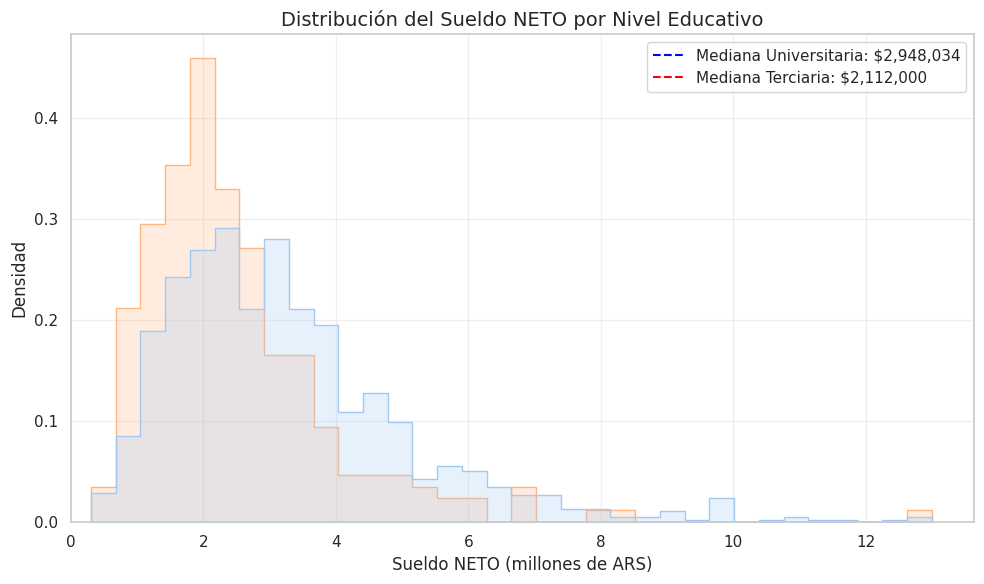

In [ ]:
df_educacion = df[df['profile_studies_level'].isin(['Universitario', 'Terciario'])]
seaborn.set_theme(style="whitegrid", palette="pastel")
fig, ax = plt.subplots(figsize=(10, 6))
seaborn.histplot(data=df_educacion, x=df_educacion['salary_monthly_NETO']/1e6, hue='profile_studies_level', element='step', stat='density', common_norm=False, ax=ax)
ax.set_title('Distribución del Sueldo NETO por Nivel Educativo', fontsize=14)
ax.set_xlabel('Sueldo NETO (millones de ARS)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_xlim(left=0)

mediana_universitario = df_educacion[df_educacion['profile_studies_level'] == 'Universitario']['salary_monthly_NETO'].median()
mediana_terciario = df_educacion[df_educacion['profile_studies_level'] == 'Terciario']['salary_monthly_NETO'].median()
ax.axvline(mediana_universitario, color='blue', linestyle='--', label=f'Mediana Universitaria: ${mediana_universitario:,.0f}')
ax.axvline(mediana_terciario, color='red', linestyle='--', label=f'Mediana Terciaria: ${mediana_terciario:,.0f}')
ax.legend()


plt.tight_layout()
plt.show()


In [ ]:
# --- 2.c.6  Análisis de independencia vía probabilidad condicional ---
# Marco teórico tomado de la clase 01 (Probabilidad): dos eventos A y B
# son independientes si y sólo si
#
#     P(A ∩ B) = P(A) · P(B)
#
# lo que equivale a AMBAS formas condicionales:
#
#     P(A | B) = P(A)     ⇔     P(B | A) = P(B)
#
# Matemáticamente estas dos condiciones son equivalentes, pero sus
# distancias numéricas |P(A|B) − P(A)| y |P(B|A) − P(B)| NO coinciden
# en general porque dependen de las masas marginales P(A) y P(B): una
# diferencia dada en la conjunta se proyecta distinto en cada
# condicional según el tamaño relativo de cada marginal. Reportar
# ambas direcciones da una lectura más robusta.
#
# Se define:
#
#   A = evento "sueldo NETO mayor que la mediana global de df_estudios"
#   B_i = evento "nivel de estudio = i-ésima subpoblación"

sal_todos = df_estudios['salary_monthly_NETO']
N_estudios = len(df_estudios)
umbral_mediana_global = sal_todos.median()
P_A = (sal_todos > umbral_mediana_global).mean()

# Subconjunto donde ocurre A (para calcular P(B | A))
df_A = df_estudios[sal_todos > umbral_mediana_global]
N_A = len(df_A)

filas_indep = [{
    'evento':       'A  =  sueldo NETO > mediana global',
    'n':            int(N_estudios),
    'probabilidad': round(P_A, 4),
}]
for nivel in SUBPOB_SELECCIONADAS:
    sub_B = df_estudios[df_estudios['profile_studies_level'] == nivel]
    n_B = len(sub_B)
    P_B = n_B / N_estudios
    P_A_dado_B = (sub_B['salary_monthly_NETO']
                  > umbral_mediana_global).mean()
    n_B_dado_A = int(
        (df_A['profile_studies_level'] == nivel).sum())
    P_B_dado_A = n_B_dado_A / N_A if N_A else float('nan')
    filas_indep.append({
        'evento':       f'B  =  "{nivel}"',
        'n':            int(n_B),
        'probabilidad': round(P_B, 4),
    })
    filas_indep.append({
        'evento':       f'A | B  ({nivel})',
        'n':            int(n_B),
        'probabilidad': round(P_A_dado_B, 4),
    })
    filas_indep.append({
        'evento':       f'B | A  ({nivel})',
        'n':            int(n_B_dado_A),
        'probabilidad': round(P_B_dado_A, 4),
    })

tabla_independencia = pd.DataFrame(filas_indep)
mostrar('2.c.6  Probabilidades marginales y condicionales '
        '(ambas direcciones)', tabla_independencia)

In [ ]:
# Distancias descriptivas en ambas direcciones
filas_brechas = []
for nivel in SUBPOB_SELECCIONADAS:
    sub_B = df_estudios[df_estudios['profile_studies_level'] == nivel]
    n_B = len(sub_B)
    P_B = n_B / N_estudios
    P_A_dado_B = (sub_B['salary_monthly_NETO']
                  > umbral_mediana_global).mean()
    P_B_dado_A = ((df_A['profile_studies_level'] == nivel).sum() / N_A
                  if N_A else float('nan'))
    filas_brechas.append({
        'subpoblación B':    nivel,
        'P(A)':              round(P_A, 4),
        'P(A|B)':            round(P_A_dado_B, 4),
        '|P(A|B) − P(A)|':   round(abs(P_A_dado_B - P_A), 4),
        'P(B)':              round(P_B, 4),
        'P(B|A)':            round(P_B_dado_A, 4),
        '|P(B|A) − P(B)|':   round(abs(P_B_dado_A - P_B), 4),
    })
brechas_independencia = pd.DataFrame(filas_brechas)
mostrar('2.c.7  Distancias descriptivas en ambas direcciones '
        '(P(A|B) vs P(A)  y  P(B|A) vs P(B))',
        brechas_independencia)

### ¿Son independientes el nivel de estudio y el sueldo NETO?

El marco teórico se toma de la clase 01 (probabilidad condicional). Dos eventos A y B son independientes si y sólo si

 >$$P(A | B) = P(A)$$

Definimos:

* **A** = evento "sueldo NETO mayor que la mediana global" (umbral calculado sobre el conjunto con estudios declarados).
* **B** = evento "nivel de estudio = X" (para cada subpoblación seleccionada).

Si las variables fueran independientes en esta muestra, las probabilidades condicionales serían similares a la marginal. Los valores observados son:

|Probabilidad| Valor | Distancia a P(A)|
|:--- |:---: |:---: |
|P(A)   marginal|0.4997	|—|
|P(A \| Universitario)	|0.5259	|0.0263|
|P(A \| Terciario) | 0.2731	|0.2265|


>**Lectura descriptiva**: las dos probabilidades condicionales no son iguales a P(A). La subpoblación Terciario muestra una distancia marcada respecto de la marginal, mientras que Universitario se aparta poco. En términos **puramente descriptivos**, esto sugiere que nivel de estudio y sueldo NETO <ins>no son independientes</ins> en esta muestra. No se realiza ningún test inferencial; una afirmación más fuerte requeriría herramientas de la parte 2 del entregable.

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)


In [ ]:
# ============================================================
# 2.d  Densidad conjunta condicional: experiencia vs sueldo + hue
# ============================================================
#
# La consigna pide dos variables numéricas y UNA variable categórica.
# Se adopta como variable categórica principal "work_seniority" por
# estar directamente vinculada a la pregunta del ejercicio 1. Como
# análisis complementario se incluye también "profile_gender" (dos
# categorías principales), con la salvedad de que la consigna pide
# una sola categórica — se declara explícitamente que el segundo
# scatter (G11) es extendido más allá del mínimo requerido.

declaracion_2d = pd.DataFrame({
    'elemento': [
        'numéricas (pedidas: 2)',
        'categórica principal (pedida: 1)',
        'categórica complementaria (extendida)',
    ],
    'elección': [
        'profile_years_experience, salary_monthly_NETO',
        'work_seniority (G10)',
        'profile_gender (G11, análisis extendido)',
    ],
})
mostrar('2.d.0  Declaración de variables del ejercicio 2d',
        declaracion_2d)

# --- 2.d.1  Por seniority ---
seniority_resumen = (
    df.groupby('work_seniority')[['profile_years_experience',
                                  'salary_monthly_NETO']]
    .agg(
        n=('salary_monthly_NETO', 'count'),
        exp_mediana=('profile_years_experience', 'median'),
        exp_q1=('profile_years_experience', lambda x: x.quantile(.25)),
        exp_q3=('profile_years_experience', lambda x: x.quantile(.75)),
        sal_mediana=('salary_monthly_NETO', 'median'),
        sal_q1=('salary_monthly_NETO', lambda x: x.quantile(.25)),
        sal_q3=('salary_monthly_NETO', lambda x: x.quantile(.75)),
    )
    .reindex(['Junior', 'Semi-Senior', 'Senior'])
    .round(0)
)
mostrar('2.d.1  Experiencia y sueldo por seniority', seniority_resumen)

### 2.d Densidad conjunta condicional: experiencia vs sueldo por categoría

Se estudia cómo se comporta la relación entre años de experiencia y sueldo NETO al condicionar por dos factores categóricos distintos: el nivel de seniority declarado y el grupo de género. El primero está directamente vinculado a la progresión profesional del respondente; el segundo permite examinar si existen brechas sistemáticas entre grupos de identidad de género dentro de cada tramo de experiencia. Aunque el análisis más básico podría hacerse con una sola variable categórica, la segunda se incluye como análisis complementario porque aporta una dimensión distinta y relevante para el tipo de preguntas que este trabajo explora.



| MEDIANA JUNIOR | MEDIANA SEMI-SENIOR | MEDIANA SENIOR |
| :--- | :--- | :--- |
| 1.55 M | 2.33 M | 3.34 M|


In [ ]:
# 1. Preparación de datos: Mediana por año de experiencia
# Filtramos para tener al menos 5 respuestas por año para la línea de tendencia
resumen_años = df.groupby('profile_years_experience')['salary_monthly_NETO'].agg(['median', 'count'])
años_validos = resumen_años[resumen_años['count'] >= 5].index
df_mediana = resumen_años.loc[años_validos].reset_index()

seaborn.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))


# Calculamos los n para la leyenda
labels_n = {s: f"{s} (n={(df['work_seniority']==s).sum()})" for s in df['work_seniority'].unique()}

seaborn.scatterplot(
    data=df,
    x='profile_years_experience',
    y=df['salary_monthly_NETO'] / 1e6, # Convertimos a millones
    hue='work_seniority',
    palette='pastel',
    alpha=0.4,
    s=30,
    edgecolor=None,
    ax=ax
)

# Line Plot de la Mediana
seaborn.lineplot(
    data=df_mediana,
    x='profile_years_experience',
    y=df_mediana['median'] / 1e6,
    color='black',
    linewidth=2,
    marker='o',
    markersize=6,
    label='Mediana por año (n ≥ 5)',
    ax=ax
)

ax.set_title('Experiencia vs sueldo NETO, condicionado por seniority',
             loc='left', fontsize=14, pad=20, color='#2e3436')
ax.set_xlabel('Años de experiencia', fontsize=12, labelpad=15)
ax.set_ylabel('Sueldo NETO (millones de ARS)', fontsize=12, labelpad=15)

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
GRUPOS_GENERO = ['Hombre Cis', 'Mujer Cis', 'Diversidades']

conteo_gender = (
    df_gender['genero_grupo'].value_counts()
    .reindex(GRUPOS_GENERO)
    .to_frame('n')
)
conteo_gender['pct'] = (
    100 * conteo_gender['n'] / conteo_gender['n'].sum()).round(2)

cobertura_gender = pd.DataFrame({
    'métrica': [
        'observaciones en df filtrado',
        'Hombre Cis',
        'Mujer Cis',
        'Diversidades (agrupación)',
        'sin género declarado (excluidas)',
        'pct considerado en el análisis',
    ],
    'valor': [
        len(df),
        int(conteo_gender.loc['Hombre Cis', 'n']),
        int(conteo_gender.loc['Mujer Cis', 'n']),
        int(conteo_gender.loc['Diversidades', 'n']),
        len(df) - len(df_gender),
        f'{100 * len(df_gender) / len(df):.2f} %',
    ],
})
mostrar('2.d.2  Cobertura del análisis por género', cobertura_gender)

In [ ]:
CATEGORIAS_DIVERSIDADES = [
    'No binarie', 'Trans', 'Queer', 'Agénero', 'Prefiero no decir',
]

print('\n  La etiqueta "Diversidades" agrupa las siguientes categorías')
print('  literales del formulario, con baja cobertura muestral individual:')
for cat in CATEGORIAS_DIVERSIDADES:
    n_cat = int((df['profile_gender'] == cat).sum())
    print(f'    · {cat:24s}  n = {n_cat}')
print('  La agrupación permite que estas identidades estén presentes en el')
print('  análisis sin producir medianas inestables por grupo.')

gender_resumen = (
    df_gender.groupby('genero_grupo')['salary_monthly_NETO']
    .describe(percentiles=[.25, .5, .75])
    .reindex(GRUPOS_GENERO)
    .round(0)
)
mostrar('2.d.3  Sueldo NETO por grupo de género', gender_resumen)

In [ ]:
# Brecha salarial estimada: se reporta para los tres grupos tomando
# "Hombre Cis" como referencia para facilitar la comparación.
med_hombre = gender_resumen.loc['Hombre Cis', '50%']
med_mujer = gender_resumen.loc['Mujer Cis', '50%']
med_diversidades = gender_resumen.loc['Diversidades', '50%']
ratio_mujer = med_mujer / med_hombre
ratio_diversidades = med_diversidades / med_hombre

brecha_tabla = pd.DataFrame({
    'métrica': [
        'mediana Hombre Cis (ARS)',
        'mediana Mujer Cis (ARS)',
        'mediana Diversidades (ARS)',
        'ratio Mujer Cis / Hombre Cis',
        'ratio Diversidades / Hombre Cis',
        'brecha relativa Mujer Cis vs Hombre Cis',
        'brecha relativa Diversidades vs Hombre Cis',
    ],
    'valor': [
        fmt_ars(med_hombre),
        fmt_ars(med_mujer),
        fmt_ars(med_diversidades),
        f'{ratio_mujer:.4f}',
        f'{ratio_diversidades:.4f}',
        f'{100 * (1 - ratio_mujer):.2f} %',
        f'{100 * (1 - ratio_diversidades):.2f} %',
    ],
})
mostrar('2.d.4  Brecha salarial entre grupos de género', brecha_tabla)

El análisis por género se realiza sobre tres grupos analíticos: Hombre Cis y Mujer Cis, que son los valores literales más numerosos del formulario, y una agrupación llamada Diversidades que reúne las categorías No binarie, Trans, Queer, Agénero y Prefiero no decir. Cada una de estas últimas tiene baja cobertura muestral individual (menos de 55 observaciones), pero agrupadas bajo una sola etiqueta alcanzan un tamaño suficiente para estadísticos descriptivos básicos, y la agrupación permite que estas identidades estén representadas en el análisis en lugar de quedar excluidas.

| MEDIANA HOMBRE CIS | MEDIANA MUJER CIS | MEDIANA DIVERSIDADES |BRECHA MUJER CIS VS HOMBRE CIS|BRECHA DIVERSIDADES VS HOMBRE CIS|
| :--- | :--- | :--- |  :--- |  :--- |
| 2.884.496 |  2.400.000 | 2.700.000| 16.80 % |6.40 %|

Las brechas relativas se calculan tomando la mediana de `Hombre Cis` como referencia. Un valor positivo indica que la mediana del grupo comparado está por debajo de la del grupo de referencia.

In [ ]:
seaborn.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

seaborn.scatterplot(data=df_gender,x='profile_years_experience',y=df['salary_monthly_NETO']/1e6, hue='genero_grupo')

ax.set_title('Experiencia vs sueldo NETO, condicionado por grupo de género',
             loc='left', fontsize=14, pad=20, color='#2e3436')
ax.set_xlabel('Años de experiencia', fontsize=12, labelpad=15)
ax.set_ylabel('Sueldo NETO (millones de ARS)', fontsize=12, labelpad=15)

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 2.e Conclusiones del ejercicio 2

* En esta muestra, y bajo los filtros aplicados, se observa una correlación de Pearson de 0.286 entre el sueldo NETO y los años de experiencia, y de 0.076 entre sueldo NETO y edad. Ambas asociaciones son positivas; la experiencia aparece como el predictor más directo del sueldo en los datos observados.
* La asociación muestral entre sueldo BRUTO y sueldo NETO es muy fuerte (Pearson = 0.947, Spearman = 0.954), con un ratio NETO/BRUTO mediano de 0.833 y un descuento relativo mediano del 16.7 %. En términos descriptivos y a efectos del análisis realizado, la columna BRUTO resulta altamente redundante con NETO: puede considerarse su remoción del formulario sin pérdida sustancial para este tipo de análisis.
* El análisis comparativo de las dos subpoblaciones más numerosas (Universitario, Terciario) muestra que la distancia |P(A|B) − P(A)| no es cercana a cero en ambos grupos (P(A) = 0.500, distancias 0.026 y 0.227). En términos descriptivos, esto sugiere que nivel de estudio y sueldo NO son independientes en esta muestra. Solo el 35 % de los respondentes declararon su nivel de estudio, lo que acota el alcance.
* Dentro de cada nivel de seniority la relación experiencia ↔ sueldo se mantiene creciente en los datos observados (G10). Entre los tres grupos analíticos de género considerados se registra, en esta muestra, una brecha relativa de 16.8 % para Mujer Cis respecto de Hombre Cis y de 6.4 % para el grupo Diversidades respecto del mismo grupo de referencia (G11). Una afirmación sólida sobre brechas poblacionales requeriría un análisis multivariado y herramientas inferenciales que exceden el alcance de esta parte.
* Respondiendo la pregunta general del ejercicio 2 ("¿qué herramientas prácticas y teóricas son útiles para explorar la base, descubrir patrones y asociaciones?"), el desarrollo de los cuatro sub-ejercicios muestra un conjunto mínimo y defendible compuesto por: histogramas y diagramas de caja para describir distribuciones marginales, coeficientes de correlación (Pearson y Spearman) y matrices de correlación para medir asociaciones entre numéricas, columnas derivadas (como DESCUENTOS = BRUTO − NETO) para caracterizar redundancia entre variables, tablas de contingencia para pares categóricos, comparación de probabilidades marginales y condicionales P(A) vs P(A|B) para el análisis de independencia y scatterplots con hue categórico para la densidad conjunta condicional. Todas estas herramientas son estrictamente descriptivas y suficientes para responder las preguntas planteadas en esta parte del entregable.